# Cloud for AI: Assignment Part 2 Modelling

## Assignment Description
The focus of this assignment is not on the ML modelling. It's about using the good working principles rather than delivering a good project!

**Objectives of the assignment:**
- Build an ML solution to the selected problem
- Do proper model selection by trying different models
- Evaluate properly!
- Think of ways to improve.
- Stay aligned with scoping and keep deployment into consideration.  

We have talked about modelling and how to write production level code.
Please follow the guidelines on the courses to build your solution.
You can always look at solutions at Kaggle!

**I ask for the following:**
- Some Data exploration with at least 2 graphs and 2 findings.
- At least 2-3 models with different complexities (examples are linear regression, logistic regression, Random Forest, XGBoost, any Neural Network)
  - Pick any models you want
- (Optional) Try tuning at least one of the models (feature selection, feature engineering, hyperparameter tuning)
- (Optional) Build an ensemble of the models you made
- Evaluate your predictions properly on the selected metrics (report any accuracy improvements on finetuning)
- Report if you are aligned with your initial scoping

**You will be evaluated on the following:**
- Your model solves the task (Do not mind the accuracy)
- You evaluate properly
- You do not fall into common pitfalls (data leakage etc)
- You deliver clean code
- You are aligned with scoping and have deployment in  

**To deliver:**
- A zip with .ipynb (or a set of .py) files with the work you have done.
- A small report (1-2 pages) describing your implementation.
- Also include the usage of any AI tools and why/how you have used them.
- (Optional) A .py script with cleaned code  

**Final Notes:**
If you have any questions, concerns, or anything you want to discuss please email me so we can sort it out!  


## Dataset

**Source**  
I used the Bird Species Classification 200 Categories dataset from Kaggle by Kedar (https://www.kaggle.com/datasets/kedarsai/bird-species-classification-220-categories/data).  

**Reason**  
I chose this dataset as it leaned the closest to my objective that is to classify a multitude of birds in the neighbourhood. While searching for an appropriate dataset, I came to the conclusion that I can't really find a good one for the birds in my neighbourhood as there isn't much interest for bird classification as opposed to the interest in North America. So that is why I chose this particular dataset and not another one closer to "home" (Belgium).

### Info provided by Kedar about the dataset
**Context**  
This Data set is a good example of of a complex Multi class classification problem. 200 classes which are divided into Train data and Test data where each class can be identified using its folder name.

**Content**  
This data set is from Caltech-UCSD Birds-200-2011 dataset, which was further cleansed into train test folders.

http://www.vision.caltech.edu/visipedia/CUB-200-2011.html

**Inspiration**  
This dataset will produce pretty good result using the Imagenet pretrained models , since the dataset has overlapping images from Imagenet.

### Function to delete a folder and it's contents

Sometimes I made a folder in the wrong place. This function is an easy way to quickly rectify any mistakes.

In [ ]:
import shutil
import os

def remove_folder(folder_path):
    """
    Removes a folder and its contents if it exists.

    Parameters:
    folder_path (str): The path to the folder to remove.
    """
    # Check if the folder exists before trying to remove it
    if os.path.exists(folder_path) and os.path.isdir(folder_path):
        # Remove the folder and its contents
        shutil.rmtree(folder_path)
        print(f"Folder '{folder_path}' and its contents have been removed.")
    else:
        print(f"The folder '{folder_path}' does not exist.")

In [ ]:
# Example:
#remove_folder("/content/bird-species-classification-220-categories/1")

### Libraries

I imported some standard libraries.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.image import imread
import random
from os import listdir

### Downloading the dataset

I chose to download the dataset with kagglehub. Then I copied the dataset to the content folder for ease of access.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kedarsai/bird-species-classification-220-categories")

print("Path to dataset files:", path)

100%|██████████| 1.06G/1.06G [00:12<00:00, 87.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kedarsai/bird-species-classification-220-categories/versions/1


Path to the dataset: /root/.cache/kagglehub/datasets/kedarsai/bird-species-classification-220-categories/versions/1

In [ ]:
import os
import shutil

# Define the paths
source_path = '/root/.cache/kagglehub/datasets/kedarsai/bird-species-classification-220-categories/versions/1'
destination_base_path = '/content/bird-species-classification-220-categories'
destination_folder = os.path.join(destination_base_path, '1')  # Initially, we'll copy as '1'

# Step 1: Create the destination folder if it doesn't exist
os.makedirs(destination_base_path, exist_ok=True)

# Step 2: Copy folder `1` from the source to the new folder in /content/
shutil.copytree(source_path, destination_folder)

# Step 3: Rename the copied folder to 'Bird Species Classification 220 Dataset'
final_folder = os.path.join(destination_base_path, 'Bird Species Classification 220 Dataset')
os.rename(destination_folder, final_folder)

print(f"Folder successfully copied and renamed to: {final_folder}")


Folder successfully copied and renamed to: /content/bird-species-classification-220-categories/Bird Species Classification 220 Dataset


We copy the dataset from the source_path to content so we can access it easier.

## Data Exploration

### Define paths & list classes

Let's verify that we indeed have 200 classes in both Train & Test.

In [ ]:
import os

BASE_DIR = "/content/bird-species-classification-220-categories/Bird Species Classification 220 Dataset"
TRAIN_DIR = os.path.join(BASE_DIR, "Train")
TEST_DIR = os.path.join(BASE_DIR, "Test")

train_classes = sorted(os.listdir(TRAIN_DIR))
test_classes = sorted(os.listdir(TEST_DIR))

print("Number of train classes:", len(train_classes))
print("Number of test classes:", len(test_classes))
print("Example classes:", train_classes[:5])

Number of train classes: 200
Number of test classes: 200
Example classes: ['Acadian_Flycatcher', 'American_Crow', 'American_Goldfinch', 'American_Pipit', 'American_Redstart']


### Do all classes in Train & Test match?

In [ ]:
# Verify that Train and Test class names match
train_classes = sorted(os.listdir(TRAIN_DIR))
test_classes = sorted(os.listdir(TEST_DIR))

# Check for any class mismatch
if train_classes == test_classes:
    print("Class names in Train and Test sets match!")
else:
    print("Class names DO NOT match!")
    # Find mismatched class names
    train_set = set(train_classes)
    test_set = set(test_classes)

    # Print out the mismatched classes
    only_in_train = train_set - test_set
    only_in_test = test_set - train_set

    print(f"Classes only in Train: {only_in_train}")
    print(f"Classes only in Test: {only_in_test}")


Class names in Train and Test sets match!


### Count images per class in Train & Test

In [ ]:
from collections import Counter

def count_images(folder):
    counts = {}
    for cls in sorted(os.listdir(folder)):
        cls_folder = os.path.join(folder, cls)
        if os.path.isdir(cls_folder):
            counts[cls] = len(os.listdir(cls_folder))
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)

print("Train images total:", sum(train_counts.values()))
print("Test images total:", sum(test_counts.values()))
print()
print("Train images average per class:", (sum(train_counts.values())/len(train_counts)))
print("Test images average per class:", (sum(test_counts.values())/len(test_counts)))


Train images total: 9414
Test images total: 2374

Train images average per class: 47.07
Test images average per class: 11.87


### Plot distribution of images per class

#### Train:

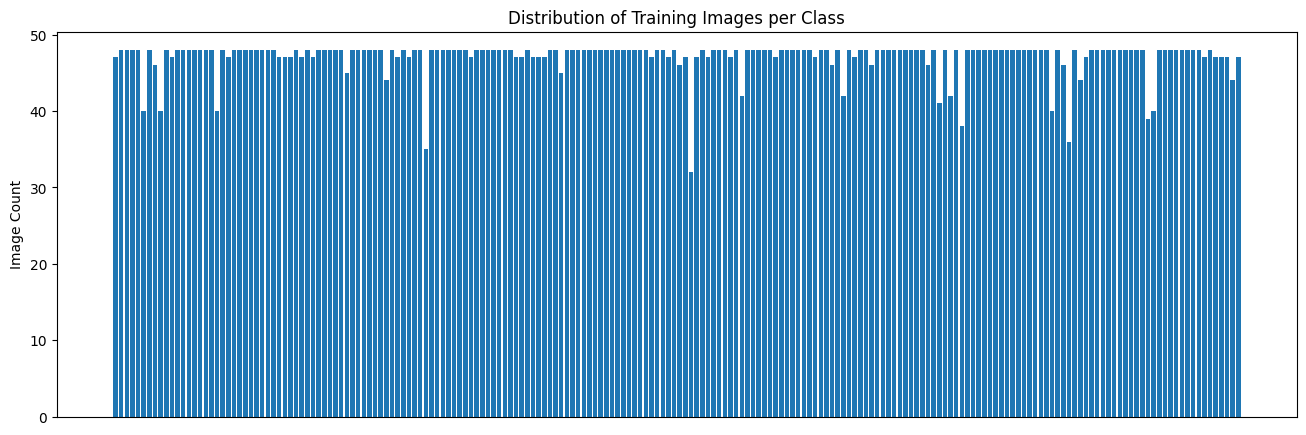

Class with fewest number of images:
Least_Auklet -> 32

Class with most number of images:
American_Crow -> 48

Classes with ≥15 fewer images than the most represented class:
Found 1 class(es).
['Least_Auklet'] ...


In [ ]:
import matplotlib.pyplot as plt

# --- Plot ---
plt.figure(figsize=(16,5))
plt.bar(train_counts.keys(), train_counts.values())
plt.xticks([], [])   # too many class names
plt.title("Distribution of Training Images per Class")
plt.ylabel("Image Count")
plt.show()

# --- Class statistics ---
min_class = min(train_counts, key=train_counts.get)
max_class = max(train_counts, key=train_counts.get)

print("Class with fewest number of images:")
print(min_class, "->", train_counts[min_class])

print("\nClass with most number of images:")
print(max_class, "->", train_counts[max_class])

# --- Classes that have 15 or more fewer images than the max class ---
threshold = train_counts[max_class] - 15
low_classes = [cls for cls, cnt in train_counts.items() if cnt <= threshold]

print("\nClasses with ≥15 fewer images than the most represented class:")
print(f"Found {len(low_classes)} class(es).")
print(low_classes[:], "...")


We can see that the distribution of images per class is quite balanced overall.

In [ ]:
# Sort the classes based on the number of images in ascending order
sorted_train_counts = sorted(train_counts.items(), key=lambda x: x[1])

# Get top 5 classes with the least number of images
top_5_least_classes = sorted_train_counts[:5]

print("Top 5 classes with the least number of images:")
for cls, count in top_5_least_classes:
    print(f"Class: {cls} -> Images: {count}")


Top 5 classes with the least number of images:
Class: Least_Auklet -> Images: 32
Class: Crested_Auklet -> Images: 35
Class: Spotted_Catbird -> Images: 36
Class: Rhinoceros_Auklet -> Images: 38
Class: Whip_poor_Will -> Images: 39


Now we know which classses were causing the "dips" in the plot.

#### Test:

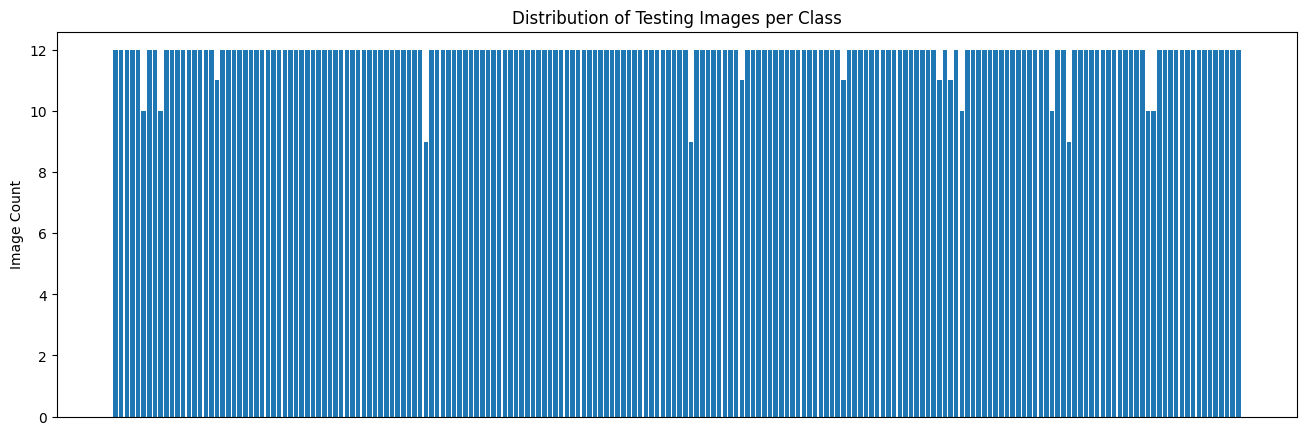

Class with fewest number of images:
Crested_Auklet -> 9

Class with most number of images:
Acadian_Flycatcher -> 12

Classes with ≥15 fewer images than the most represented class:
Found 0 class(es).
[] ...


In [ ]:
import matplotlib.pyplot as plt

# --- Plot ---
plt.figure(figsize=(16,5))
plt.bar(test_counts.keys(), test_counts.values())
plt.xticks([], [])   # too many class names
plt.title("Distribution of Testing Images per Class")
plt.ylabel("Image Count")
plt.show()

# --- Class statistics ---
min_class = min(test_counts, key=test_counts.get)
max_class = max(test_counts, key=test_counts.get)

print("Class with fewest number of images:")
print(min_class, "->", test_counts[min_class])

print("\nClass with most number of images:")
print(max_class, "->", test_counts[max_class])

# --- Classes that have 15 or more fewer images than the max class ---
threshold = test_counts[max_class] - 15
low_classes = [cls for cls, cnt in train_counts.items() if cnt <= threshold]

print("\nClasses with ≥15 fewer images than the most represented class:")
print(f"Found {len(low_classes)} class(es).")
print(low_classes[:], "...")

Here too, we see a well balanced distribution of images per class.

In [ ]:
# Sort the classes based on the number of images in ascending order
sorted_test_counts = sorted(test_counts.items(), key=lambda x: x[1])

# Get top 5 classes with the least number of images
top_5_least_classes = sorted_test_counts[:5]

print("Top 5 classes with the least number of images:")
for cls, count in top_5_least_classes:
    print(f"Class: {cls} -> Images: {count}")

Top 5 classes with the least number of images:
Class: Crested_Auklet -> Images: 9
Class: Least_Auklet -> Images: 9
Class: Spotted_Catbird -> Images: 9
Class: American_Three_toed_Woodpecker -> Images: 10
Class: Baird_Sparrow -> Images: 10


Again, we look at which classes caused the dips to get an idea.

### Check if all images are loadable (detect corrupted images)

This is very important. If even one of our images is corrupted and we try to give it to our model, the model will just crash.

To solve this we make sure that we don't have corrupted images and if we do, we will remove them from both Train and Test.

In [ ]:
import cv2
from tqdm import tqdm

corrupted_train = []
corrupted_test = []

def check_corrupted(base_dir, class_counts):
    corrupted = []
    for cls in tqdm(class_counts.keys(), desc=f"Checking images in {base_dir}"):
        cls_dir = os.path.join(base_dir, cls)
        for img_name in os.listdir(cls_dir):
            path = os.path.join(cls_dir, img_name)
            img = cv2.imread(path)
            if img is None:
                corrupted.append(path)
    return corrupted

corrupted_train = check_corrupted(TRAIN_DIR, train_counts)
corrupted_test  = check_corrupted(TEST_DIR, test_counts)

print("\n \nCorrupted images in TRAIN:", len(corrupted_train))
print("Corrupted images in TEST:", len(corrupted_test))


Checking images in /content/bird-species-classification-220-categories/Bird Species Classification 220 Dataset/Train: 100%|██████████| 200/200 [00:18<00:00, 11.00it/s]
Checking images in /content/bird-species-classification-220-categories/Bird Species Classification 220 Dataset/Test: 100%|██████████| 200/200 [00:05<00:00, 39.44it/s]


 
Corrupted images in TRAIN: 0
Corrupted images in TEST: 0


Luckily it seems we don't need to worry about corrupted images.

### Inspect image formats (PNG/JPG/JPEG/etc.)

No we will try to see if all images in our dataset have the same format. If not we will need to make sure that we choose one. Uniformity is important.

#### Train:

In [ ]:
from collections import defaultdict

formats = defaultdict(int)

for cls in train_classes:
    folder = os.path.join(TRAIN_DIR, cls)
    for file in os.listdir(folder):
        ext = file.split(".")[-1].lower()
        formats[ext] += 1

print("Image formats:", formats)


Image formats: defaultdict(<class 'int'>, {'jpg': 9414})


All images have the `.jpg` format.

#### Test:

In [ ]:
from collections import defaultdict

formats = defaultdict(int)

for cls in test_classes:
    folder = os.path.join(TEST_DIR, cls)
    for file in os.listdir(folder):
        ext = file.split(".")[-1].lower()
        formats[ext] += 1

print("Image formats:", formats)

Image formats: defaultdict(<class 'int'>, {'jpg': 2374})


All images have the `.jpg` format.

### Collect image resolutions (width, height) for both Train & Test set

Now, we want to know which input size is appropriate for this dataset. That input size is the one we will be giving to our model. This decision isn't an easy one.

We could take the minimum, maximum, P25 or P75.

#### Train:

In [ ]:
train_image_widths = []
train_image_heights = []

for cls in tqdm(train_classes, desc="Collecting image sizes"):
    folder = os.path.join(TRAIN_DIR, cls)
    for file in os.listdir(folder):
        path = os.path.join(folder, file)
        img = cv2.imread(path)
        if img is not None:
            h, w = img.shape[:2]
            train_image_widths.append(w)
            train_image_heights.append(h)

print("Collected sizes:", len(train_image_widths))

Collected sizes: 9414


#### Test:

In [ ]:
test_image_widths = []
test_image_heights = []

for cls in tqdm(test_classes, desc="Collecting image sizes"):
    folder = os.path.join(TEST_DIR, cls)
    for file in os.listdir(folder):
        path = os.path.join(folder, file)
        img = cv2.imread(path)
        if img is not None:
            h, w = img.shape[:2]
            test_image_widths.append(w)
            test_image_heights.append(h)

print("Collected sizes:", len(test_image_widths))

Collected sizes: 2374


### Plot image size distributions

#### Train:

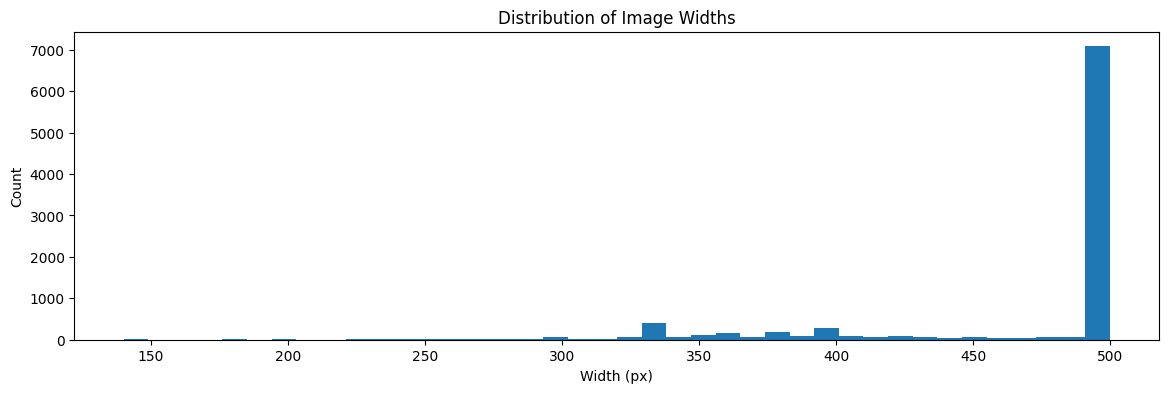

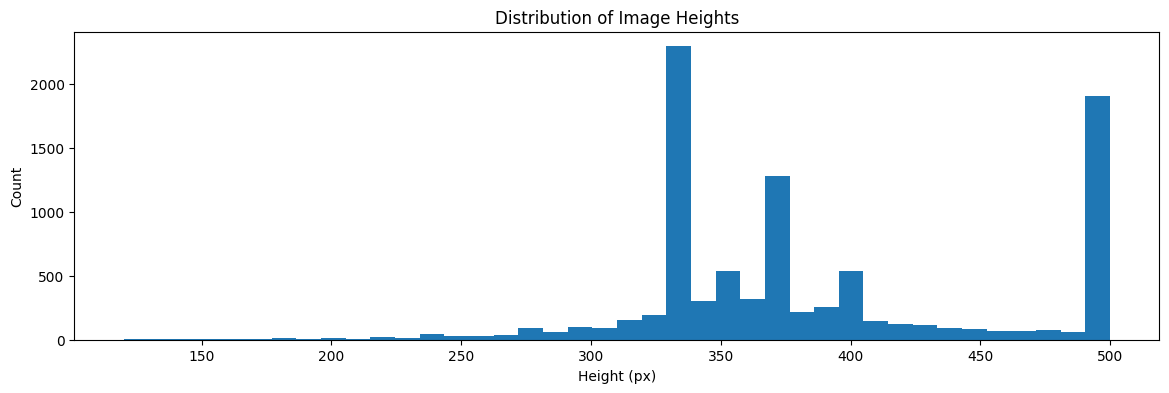

In [ ]:
plt.figure(figsize=(14,4))
plt.hist(train_image_widths, bins=40)
plt.title("Distribution of Image Widths")
plt.xlabel("Width (px)"); plt.ylabel("Count")
plt.show()

plt.figure(figsize=(14,4))
plt.hist(train_image_heights, bins=40)
plt.title("Distribution of Image Heights")
plt.xlabel("Height (px)"); plt.ylabel("Count")
plt.show()



Most of the images have a width of 500px. However, it sees that for the height it is more spread out with the hightest being around 340px.

#### Test:

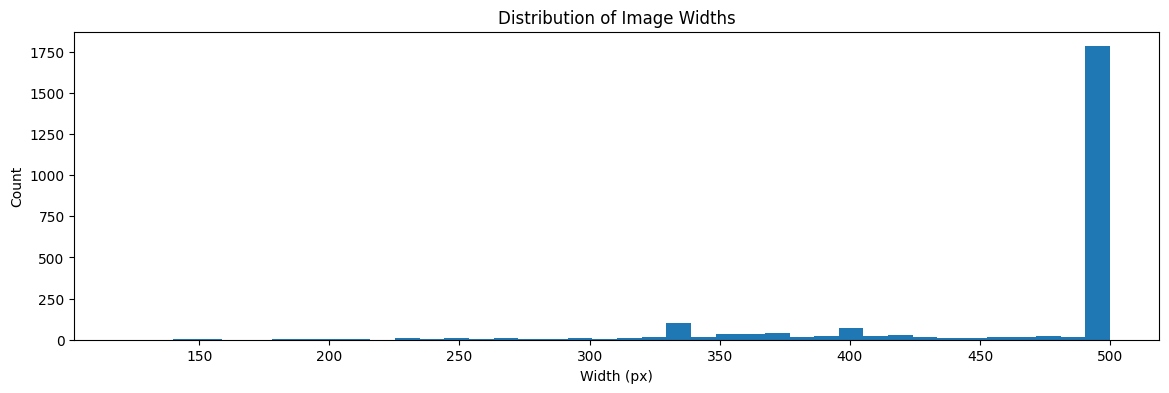

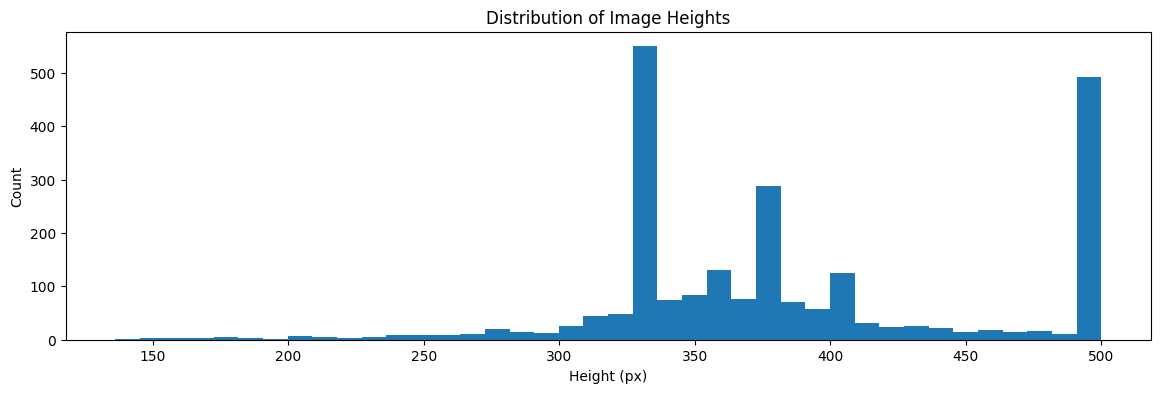

In [ ]:
plt.figure(figsize=(14,4))
plt.hist(test_image_widths, bins=40)
plt.title("Distribution of Image Widths")
plt.xlabel("Width (px)"); plt.ylabel("Count")
plt.show()

plt.figure(figsize=(14,4))
plt.hist(test_image_heights, bins=40)
plt.title("Distribution of Image Heights")
plt.xlabel("Height (px)"); plt.ylabel("Count")
plt.show()


We get a similar result for images in the Test folder.

### Compute min/max/P25/P75 for image sizes

Only for the Train, because our model cannot know of information about the Test.  
We aim to prevent Data Leakage.

If we were to include Test here, some information could leak about the Test images. We need to prevent this at all costs.

In [ ]:
import numpy as np

widths = np.array(train_image_widths)
heights = np.array(train_image_heights)

stats = {
    "min_width": widths.min(),
    "max_width": widths.max(),
    "P25_width": np.percentile(widths, 25),
    "P75_width": np.percentile(widths, 75),
    "min_height": heights.min(),
    "max_height": heights.max(),
    "P25_height": np.percentile(heights, 25),
    "P75_height": np.percentile(heights, 75),
}

for k, v in stats.items():
    print(f"{k}: {v}")


min_width: 140
max_width: 500
P25_width: 496.0
P75_width: 500.0
min_height: 120
max_height: 500
P25_height: 333.0
P75_height: 433.0


Our expectations are met. We get around the same numbers as we mentioned when plotting the image sizes.

### Show 4 random samples per class (visual inspection)

To get a better idea of what sort of images, backgrounds or objects we will deal with, we can plot some images.

In [ ]:
import random
import matplotlib.pyplot as plt

random.seed(42) # reproduciblility
sample_classes = random.sample(train_classes, 10)

for cls in sample_classes:
    folder = os.path.join(TRAIN_DIR, cls)
    sample_imgs = random.sample(os.listdir(folder), 4)

    plt.figure(figsize=(10,3))
    plt.suptitle(f"Class: {cls}", fontsize=14)

    for idx, img_name in enumerate(sample_imgs):
        img = cv2.imread(os.path.join(folder, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1,4,idx+1)
        plt.imshow(img)
        plt.axis("off")

    plt.show()


Output hidden; open in https://colab.research.google.com to view.

We can see varied backgrounds, branches, image sizes and objects. Because of the variation I see in these samples, I hope to not encounter the same problem as people have in the past (e.g. white snow for foxes, fingers for fish used to classify them).

### Compare Train vs Test distribution

We can compare the amount of images in Train and Test directly next to each other.

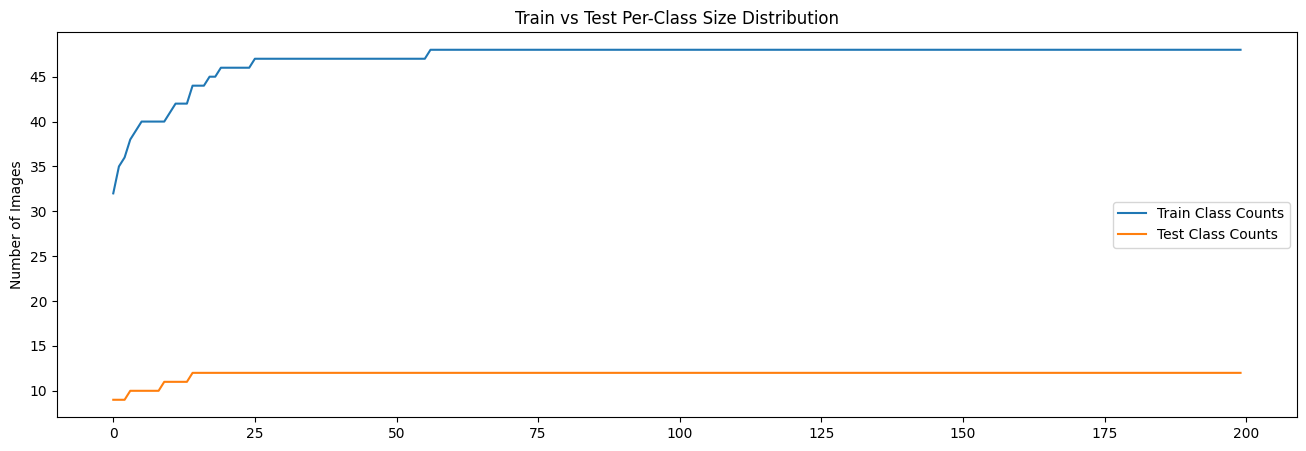

In [ ]:
plt.figure(figsize=(16,5))
plt.plot(sorted(train_counts.values()), label="Train Class Counts")
plt.plot(sorted(test_counts.values()), label="Test Class Counts")
plt.title("Train vs Test Per-Class Size Distribution")
plt.ylabel("Number of Images")
plt.legend()
plt.show()


We see that while we have around 45 images for each class in Train, we have around 12 images in Test.

We can conclude that while we might have a lot of images overall, there aren't a lot of images per class for either Train or Test.

## Deciding input image size

Now that we have some numbers and plots to base our decisions on, we can choose our input image size.

**What the exploration shows**  

Widths:  

- P25 = 496 px, P75 = 500 px  

Heights:  

- P25 = 333 px, P75 = 433 px  

Insights:  

- Almost all images are near 500 px width, but heights vary more (120–500 px).  

- Dataset is not square, but close to portrait 500×400.  

**Tings to keep in mind**  

Cloud inference feeding an app:  

- Latency matters  

- Lower resolution = faster inference  

- Enough detail to recognize bird species (fine-grained classification)  

**Possible choices**

Here are the main candidates:

| Option                | Size                        | Pros                         | Cons                    |
| --------------------- | --------------------------- | ---------------------------- | ----------------------- |
| **224×224**           | Standard (MobileNet/ResNet) | Very fast, common            | Some detail may be lost |
| **256×256**           | Balanced                    | Good compromise              | Slightly heavier        |
| **299×299**           | Inception size              | Better fine-grained features | Slower                  |
| **380×380**           | EfficientNet B3 sweet spot  | Very strong accuracy         | Higher cost             |
| **448×448 / 500×500** | Near original size          | Best detail                  | Slow, heavy             |


**My choice**  

I will go with ` 256×256` for the input image size for now, maybe we will need the `224x224` if the former choice is too slow for inference.  

Why 256×256 is the right choice:

It works well for fine-grained classification. We will have a good balance between accuracy & inference latency. It will also  reduce compute costs.

## Choosing a baseline

Choosing a baseline was not easy. An example would be to use the accuracy of the Merlin Bird ID app, but that would be impossible (both in time and resources) for me to beat.

Another possible baseline could be the HLP (human-level-performance). However, this too would be very hard to beat (assuming experts).

You could try to always predict the class with the most presence in the dataset, but as our dataset is quite balanced this wouldn't be that good.

So if I wanted the most simple baseline there could be, then that would be a random classifier.

This means that if I need to classify 200 classes. The model would have an accuracy of about 0.5%. We will surely beat that.

My personal target is to reach at least 60% or above, I know we may not reach this with the amount of images we currently have combined with the numerous amount of classes.

This means we could later cut down on the number of classes. We could also try to enlarge our dataset using image augmentation.





## Choosing models

1. Model 1 (Simple CNN)
2. Model 2 (Deep CNN)
3. Model 3 (Pretrained: MobilenNetV2)


First, we will try to see how good a simple CNN will solve the problem.  
Then, we will try to use a deeper CNN to see if it will preform better.  
Finally, we try and see how a pretrained CNN like MobileNetV2 preforms.  

We will compare, evaluate the models. Afterwards, we will improve and fine-tune the best one.

## Reducing complexity

I realized that if I didn't reduce the complexity of this problem, the training time would take too long to finish and that I wouldn't be able to complete this assignment in a proper manner.  

So, instead of trying to correctly classify all 200 classes, I will pick 25.

Some of them are bird species that were soaring in the Belgian skies in the past or do today. I will try to preserve our main idea of classifying "Belgian" birds, even though the dataset is American.

**Belgian-aligned as much as possible:**
<br>

1. Mallard

2. House_Sparrow

3. Common_Raven

4. Yellow_billed_Cuckoo

5. Ring_billed_Gull  
<br>

6. Horned_Lark

7. Bank_Swallow

8. Cedar_Waxwing

9. European_Goldfinch  

10. Gadwall  
<br>

11. Gray_Catbird

12. Great_Grey_Shrike

13. Herring_Gull

14. Hooded_Merganser  

15. House_Wren  
<br>

16. Northern_Flicker

17. Northern_Fulmar

18. Painted_Bunting

19. Pied_billed_Grebe

20. Pileated_Woodpecker  
<br>

21. Purple_Finch

22. Red_breasted_Merganser

23. Red_winged_Blackbird

24. Red_eyed_Vireo

25. Summer_Tanager  
<br>

Some of these were chosen based on these links:
- https://picturebirdai.com/region/Belgium-Country.html
-  https://en.wikipedia.org/wiki/List_of_birds_of_Belgium  



Select classes:

In [ ]:
import os

BASE_DIR = "/content/bird-species-classification-220-categories/Bird Species Classification 220 Dataset"
TRAIN_DIR = os.path.join(BASE_DIR, "Train")
TEST_DIR = os.path.join(BASE_DIR, "Test")

SELECTED_CLASSES_25 = [
    # Original 7 "Belgian" species
    "Mallard",
    "House_Sparrow",
    "Common_Raven",
    "Yellow_billed_Cuckoo",
    "Ring_billed_Gull",
    "Horned_Lark",
    "Bank_Swallow",

    # 18 other species
    "Cedar_Waxwing",
    "European_Goldfinch",
    "Gadwall",
    "Gray_Catbird",
    "Great_Grey_Shrike",
    "Herring_Gull",
    "Hooded_Merganser",
    "House_Wren",
    "Northern_Flicker",
    "Northern_Fulmar",
    "Painted_Bunting",
    "Pied_billed_Grebe",
    "Pileated_Woodpecker",
    "Purple_Finch",
    "Red_breasted_Merganser",
    "Red_winged_Blackbird",
    "Red_eyed_Vireo",
    "Summer_Tanager"
]

print("Selected classes (25):")
for c in SELECTED_CLASSES_25:
    print("-", c)




Selected classes (25):
- Mallard
- House_Sparrow
- Common_Raven
- Yellow_billed_Cuckoo
- Ring_billed_Gull
- Horned_Lark
- Bank_Swallow
- Cedar_Waxwing
- European_Goldfinch
- Gadwall
- Gray_Catbird
- Great_Grey_Shrike
- Herring_Gull
- Hooded_Merganser
- House_Wren
- Northern_Flicker
- Northern_Fulmar
- Painted_Bunting
- Pied_billed_Grebe
- Pileated_Woodpecker
- Purple_Finch
- Red_breasted_Merganser
- Red_winged_Blackbird
- Red_eyed_Vireo
- Summer_Tanager


Create filtered Train & Test folders:

We will make a new dataset for our 25 chosen bird species called `birds_filtered_25`.

In [ ]:
import shutil

FILTERED_DIR = "/content/birds_filtered_25"
TRAIN_FILTERED = os.path.join(FILTERED_DIR, "Train")
TEST_FILTERED = os.path.join(FILTERED_DIR, "Test")

# Create root folders
os.makedirs(TRAIN_FILTERED, exist_ok=True)
os.makedirs(TEST_FILTERED, exist_ok=True)

print("Created filtered dataset directories.")



Created filtered dataset directories.


In [ ]:
# Copy only the 25 selected classes into new dataset
for cls in SELECTED_CLASSES_25:
    src_train = os.path.join(TRAIN_DIR, cls)
    src_test  = os.path.join(TEST_DIR, cls)

    dst_train = os.path.join(TRAIN_FILTERED, cls)
    dst_test  = os.path.join(TEST_FILTERED, cls)

    if os.path.exists(src_train):
        shutil.copytree(src_train, dst_train, dirs_exist_ok=True)
    else:
        print("WARNING: Train folder missing for:", cls)

    if os.path.exists(src_test):
        shutil.copytree(src_test, dst_test, dirs_exist_ok=True)
    else:
        print("WARNING: Test folder missing for:", cls)

print("Finished copying selected classes.")


Finished copying selected classes.


Chack if filtered Train & Test match:

In [ ]:
# Verify that Train and Test class names match
train_classes = sorted(os.listdir(TRAIN_FILTERED))
test_classes = sorted(os.listdir(TEST_FILTERED))

# Check for any class mismatch
if train_classes == test_classes:
    print("Class names in Train and Test sets match!")
else:
    print("Class names DO NOT match!")
    # Find mismatched class names
    train_set = set(train_classes)
    test_set = set(test_classes)

    # Print out the mismatched classes
    only_in_train = train_set - test_set
    only_in_test = test_set - train_set

    print(f"Classes only in Train: {only_in_train}")
    print(f"Classes only in Test: {only_in_test}")

Class names in Train and Test sets match!


In [ ]:
from collections import Counter
import numpy as np

def count_images(folder):
    counts = {}
    for cls in sorted(os.listdir(folder)):
        cls_folder = os.path.join(folder, cls)
        if os.path.isdir(cls_folder):
            counts[cls] = len(os.listdir(cls_folder))
    return counts

train_counts = count_images(TRAIN_FILTERED)
test_counts  = count_images(TEST_FILTERED)

print("Train images total:", sum(train_counts.values()))
print("Test images total:", sum(test_counts.values()))
print()
print("Train images average:", (sum(train_counts.values())/len(train_counts)))
print("Test images average", (sum(test_counts.values())/len(train_counts)))

Train images total: 1193
Test images total: 300

Train images average: 47.72
Test images average 12.0


In [ ]:
num_classes=len(SELECTED_CLASSES_25)
print("Number of classes:", num_classes)

Number of classes: 25


Now, we can be quite sure that the new dataset is okay.

## Preprocessing

Now we can begin preprocessing our dataset.

We are making preprocessing pipeline functions to easily work with our dataset and the models we have chosen.



Create augmentation layer:

In [ ]:
import tensorflow as tf
import os

def build_augmentation_layer():
    return tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.10),
        tf.keras.layers.RandomZoom(0.15),
        tf.keras.layers.RandomContrast(0.15),
        tf.keras.layers.RandomBrightness(factor=0.15),
    ], name="data_augmentation")

Load datasets from directory:

In [ ]:
def load_datasets(train_dir, test_dir, img_size, batch_size, seed):
    train_ds = tf.keras.preprocessing.image_dataset_from_directory(
        train_dir,
        labels="inferred",
        label_mode="categorical",
        batch_size=batch_size,
        image_size=img_size,
        shuffle=True,
        seed=seed,
    )

    test_ds = tf.keras.preprocessing.image_dataset_from_directory(
        test_dir,
        labels="inferred",
        label_mode="categorical",
        batch_size=batch_size,
        image_size=img_size,
        shuffle=False
    )

    class_names = train_ds.class_names
    num_classes = len(class_names)

    return train_ds, test_ds, class_names, num_classes


Split validation set:

In [ ]:
def split_validation(train_ds, val_split):
    val_size = int(val_split * len(train_ds))
    val_ds = train_ds.take(val_size)
    train_ds = train_ds.skip(val_size)
    return train_ds, val_ds


Create preprocessing functions:

In [ ]:
def build_preprocess_fn(augmentation_layer=None):
    normalization = tf.keras.layers.Rescaling(1./255)

    def preprocess_train(image, label):
        image = normalization(image)
        if augmentation_layer:
            image = augmentation_layer(image)
        return image, label

    def preprocess_eval(image, label):
        image = normalization(image)
        return image, label

    return preprocess_train, preprocess_eval


Apply preprocessing & performance optimizations:

In [ ]:
def apply_pipeline(train_ds, val_ds, test_ds, preprocess_train, preprocess_eval):
    AUTOTUNE = tf.data.AUTOTUNE

    train_ds = train_ds.map(preprocess_train).cache().prefetch(AUTOTUNE)
    val_ds   = val_ds.map(preprocess_eval).cache().prefetch(AUTOTUNE)
    test_ds  = test_ds.map(preprocess_eval).cache().prefetch(AUTOTUNE)

    return train_ds, val_ds, test_ds


Main preprocess function calling all the other functions:

In [ ]:
def prepare_datasets(
    train_dir,
    test_dir,
    img_size=(256, 256),
    batch_size=32,
    val_split=0.20,
    seed=42,
    use_augmentation=True
):
    # 1) Augmentation
    augmentation_layer = build_augmentation_layer() if use_augmentation else None

    # 2) Load raw datasets
    train_ds, test_ds, class_names, num_classes = load_datasets(
        train_dir, test_dir, img_size, batch_size, seed
    )

    # 3) Validation split
    train_ds, val_ds = split_validation(train_ds, val_split)

    # 4) Preprocessing functions
    preprocess_train, preprocess_eval = build_preprocess_fn(augmentation_layer)

    # 5) Apply pipeline + performance optimizations
    train_ds, val_ds, test_ds = apply_pipeline(
        train_ds, val_ds, test_ds,
        preprocess_train, preprocess_eval
    )

    return train_ds, val_ds, test_ds, class_names, num_classes


Now that we have our pipeline ready. We can begin building our first model.

## Model 1: Simple CNN

Import all needed libraries:

In [ ]:
import tensorflow as tf
from tensorflow.keras.metrics import Precision, Recall
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns

Make sure we prepare our correct filtered dataset:

In [ ]:
train_ds, val_ds, test_ds, class_names, num_classes = prepare_datasets(TRAIN_FILTERED, TEST_FILTERED, img_size=(256, 256), batch_size=32, val_split=0.20, seed=42, use_augmentation=False)

Found 1193 files belonging to 25 classes.
Found 300 files belonging to 25 classes.


Build the model:

In [ ]:
import tensorflow as tf

def build_simple_cnn(input_shape=(256, 256, 3), num_classes=25):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation="relu", padding="same", input_shape=input_shape),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, (3,3), activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(128, (3,3), activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])

    return model


Compile the model:

In [ ]:
simple_cnn = build_simple_cnn(
    input_shape=(256, 256, 3),
    num_classes=num_classes
)

simple_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        Precision(name="precision"),
        Recall(name="recall")
    ]
)

simple_cnn.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    16,777,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,873,817 (64.37 MB)

 Trainable params: 16,873,817 (64.37 MB)

 Non-trainable params: 0 (0.00 B)

We use callbacks to save the best model:

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5, # after 5 times that the val_loss isn't improving we stop so we don't waste precious time
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath="simple_cnn_best.keras",
        monitor="val_loss",
        save_best_only=True
    )
]


Train the model:

In [ ]:
history_simple_cnn = simple_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks
)


Epoch 1/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 21s 326ms/step - accuracy: 0.0350 - loss: 3.8226 - precision: 0.0726 - recall: 0.0060 - val_accuracy: 0.0625 - val_loss: 3.1987 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - accuracy: 0.0564 - loss: 3.1706 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.0670 - val_loss: 3.1430 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 196ms/step - accuracy: 0.1177 - loss: 3.0813 - precision: 0.2635 - recall: 0.0014 - val_accuracy: 0.1250 - val_loss: 2.8782 - val_precision: 0.8333 - val_recall: 0.0223
Epoch 4/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 198ms/step - accuracy: 0.2192 - loss: 2.7538 - precision: 0.5692 - recall: 0.0334 - val_accuracy: 0.2991 - val_loss: 2.5315 - val_precision: 0.6400 - val_recall: 0.0714
Epoch 5/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - accuracy: 0.3568 - loss: 2.2822 - precision: 0.6099 - recall: 0.0909 - val_accura

We can see that the val_loss didn't improve anymore after the 10th epoch.

Visual representation of when the model overfitted:

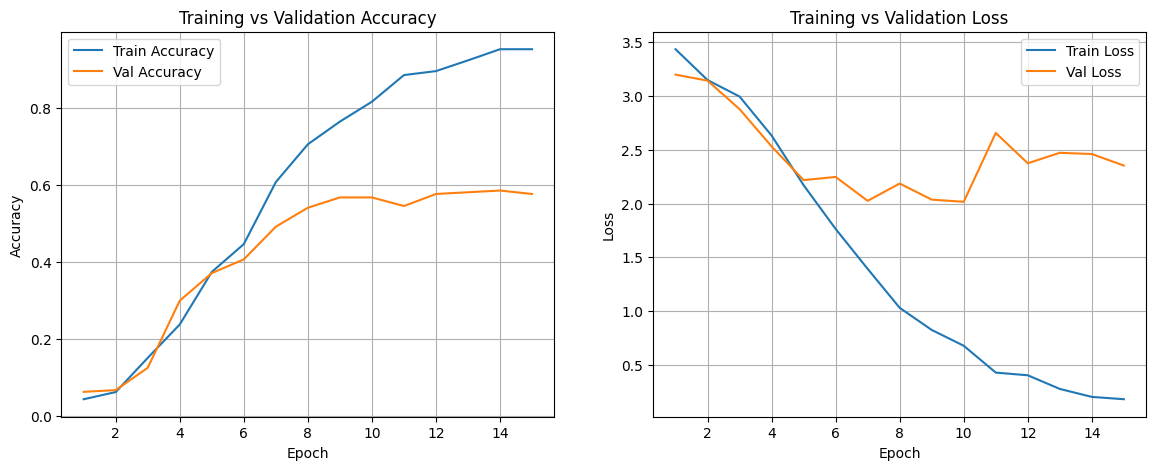

In [ ]:
import matplotlib.pyplot as plt

def plot_training_curves(history):
    acc      = history.history["accuracy"]
    val_acc  = history.history["val_accuracy"]
    loss     = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(epochs, acc, label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Val Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Val Loss")
    plt.title("Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

    plt.show()

plot_training_curves(history_simple_cnn)

We can clearly see that in the 10th epoch the model had the lowest amount of loss. The val_accuarcy didn't break through the 60%.

Looking at some other metrics:

In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Get predictions
y_pred_probs = simple_cnn.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Get true labels
y_true = np.concatenate([np.argmax(y, axis=1) for _, y in test_ds])

# Metrics
precision = precision_score(y_true, y_pred, average="macro")
recall = recall_score(y_true, y_pred, average="macro")
f1 = f1_score(y_true, y_pred, average="macro")

print("Macro Precision:", round(precision, 4))
print("Macro Recall:", round(recall, 4))
print("Macro F1-score:", round(f1, 4))


10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 166ms/step
Macro Precision: 0.2152
Macro Recall: 0.2133
Macro F1-score: 0.1973


The SimpleCNN doesn't really look promising.

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names))


                        precision    recall  f1-score   support

          Bank_Swallow       0.12      0.17      0.14        12
         Cedar_Waxwing       0.00      0.00      0.00        12
          Common_Raven       0.33      0.25      0.29        12
    European_Goldfinch       0.00      0.00      0.00        12
               Gadwall       0.18      0.33      0.24        12
          Gray_Catbird       0.18      0.25      0.21        12
     Great_Grey_Shrike       0.11      0.08      0.10        12
          Herring_Gull       0.00      0.00      0.00        12
      Hooded_Merganser       0.32      0.50      0.39        12
           Horned_Lark       0.29      0.42      0.34        12
         House_Sparrow       0.20      0.25      0.22        12
            House_Wren       0.00      0.00      0.00        12
               Mallard       0.38      0.25      0.30        12
      Northern_Flicker       0.00      0.00      0.00        12
       Northern_Fulmar       0.17      

Our model doesn't seem to know about the Herring_Gull and European_Goldfish classes.

The accuracy, macro avg, weighted avg isn't something to write home about.

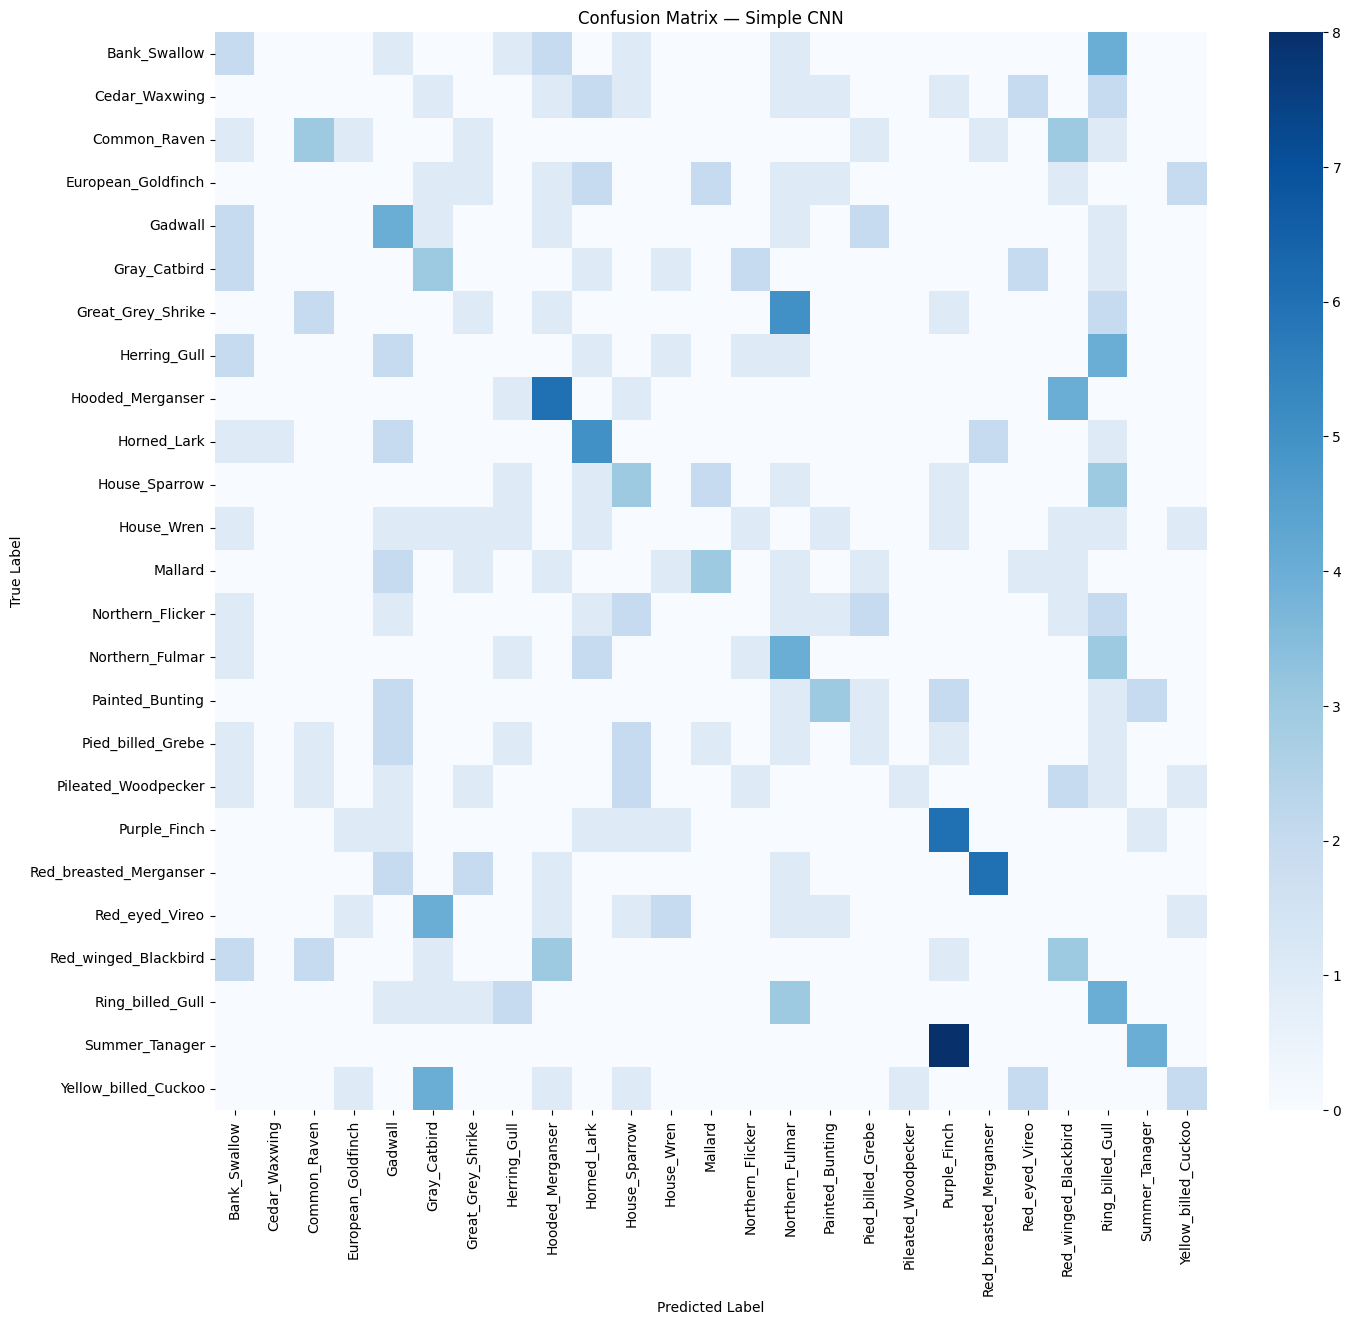

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix — Simple CNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [ ]:
simple_cnn.metrics_names

['loss', 'compile_metrics']

In [ ]:
results = simple_cnn.evaluate(test_ds)
print(f"Simple CNN Test Loss: {results[0]:.4f}") # test_loss


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1887 - loss: 3.7336 - precision: 0.2856 - recall: 0.1181
Simple CNN Test Loss: 3.3959


#### Summary of the results

* The model **overfits**: training accuracy high, validation/test metrics low.
* The current Simple CNN is **insufficient to generalize** to 25-class classification with limited samples per class.
* Poor macro F1 and recall indicate that **many classes are not being recognized**, even if overall accuracy appears moderate during training.
* Validation accuracy during training is **not a reliable indicator** of performance on the full test set due to dataset size and batch averaging.  

#### What does this mean for the model?

* The baseline CNN **can learn features from the training set**, but fails to generalize.
* Current architecture is **too simple for 25-class classification** with few samples per class, especially without data augmentation.
* The evaluation shows that the model requires **better regularization and generalization strategies**.  

#### Future steps to take to fix these problems

1. **Data Augmentation:** Enable horizontal flip, rotation, zoom, contrast, and brightness adjustments to improve generalization.
2. **Regularization:** Increase dropout (0.3 --> 0.5) and consider L2 weight regularization in Conv/Dense layers.
3. **Model capacity:** Slightly deeper CNN or wider layers can help, but monitor overfitting.
4. **Transfer learning:** Use pretrained models (MobileNetV2, EfficientNetB0) with frozen base layers and train only top layers initially.
5. **Class balancing / oversampling:** If allowed, ensure all classes have sufficient representation during training.  

## Model 2: Deep CNN

Now that we learned a few lessons, we can try to beat the previous Simple CNN model with a deeper version.

We won't use data augmentation yet, because we want to see if a "deeper" or "complexer" network might beat our first model.

Found 1193 files belonging to 25 classes.
Found 300 files belonging to 25 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 256, 256, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    33,554,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 25)             │         6,425 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,848,121 (129.12 MB)

 Trainable params: 33,848,121 (129.12 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 49s 880ms/step - accuracy: 0.0334 - loss: 4.0319 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.0580 - val_loss: 3.6985 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 14s 447ms/step - accuracy: 0.0543 - loss: 3.6106 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.0580 - val_loss: 3.4150 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 291ms/step - accuracy: 0.0518 - loss: 3.3806 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.0580 - val_loss: 3.3084 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 264ms/step - accuracy: 0.0490 - loss: 3.2943 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.0179 - val_loss: 3.2644 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 268ms/step - accuracy: 0.0323 - loss: 3.2577 - precis

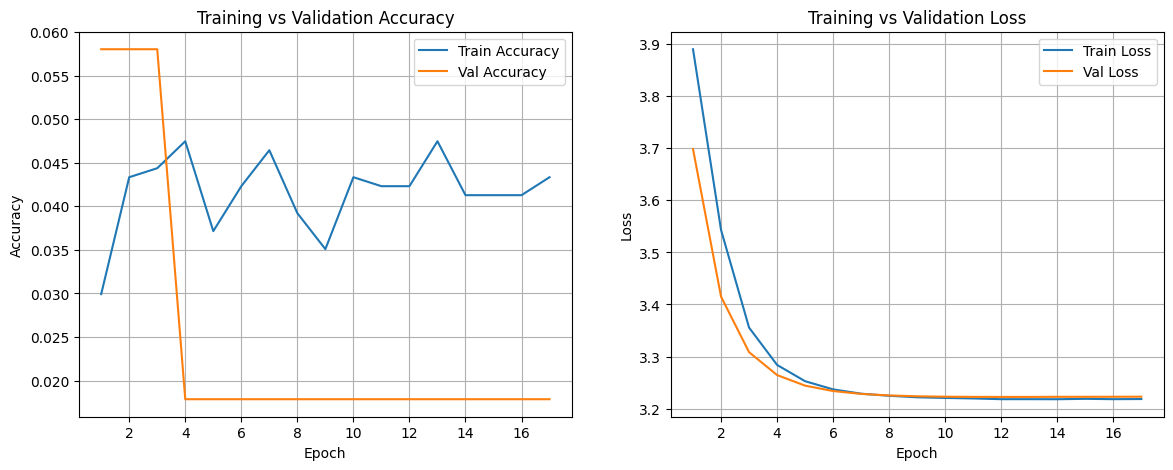

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 278ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Macro Precision: 0.0016
Macro Recall: 0.04
Macro F1-score: 0.0031
                        precision    recall  f1-score   support

          Bank_Swallow       0.00      0.00      0.00        12
         Cedar_Waxwing       0.00      0.00      0.00        12
          Common_Raven       0.00      0.00      0.00        12
    European_Goldfinch       0.04      1.00      0.08        12
               Gadwall       0.00      0.00      0.00        12
          Gray_Catbird       0.00      0.00      0.00        12
     Great_Grey_Shrike       0.00      0.00      0.00        12
          Herring_Gull       0.00      0.00      0.00        12
      Hooded_Merganser       0.00      0.00      0.00        12
           Horned_Lark       0.00      0.00      0.00        12
         House_Sparrow       0.00      0.00      0.00        12
            House_Wren       0.00      0.00      0.00        12
               Mallard       0.00      0.00      0.00        12
      Northern_Flicker       0.00    

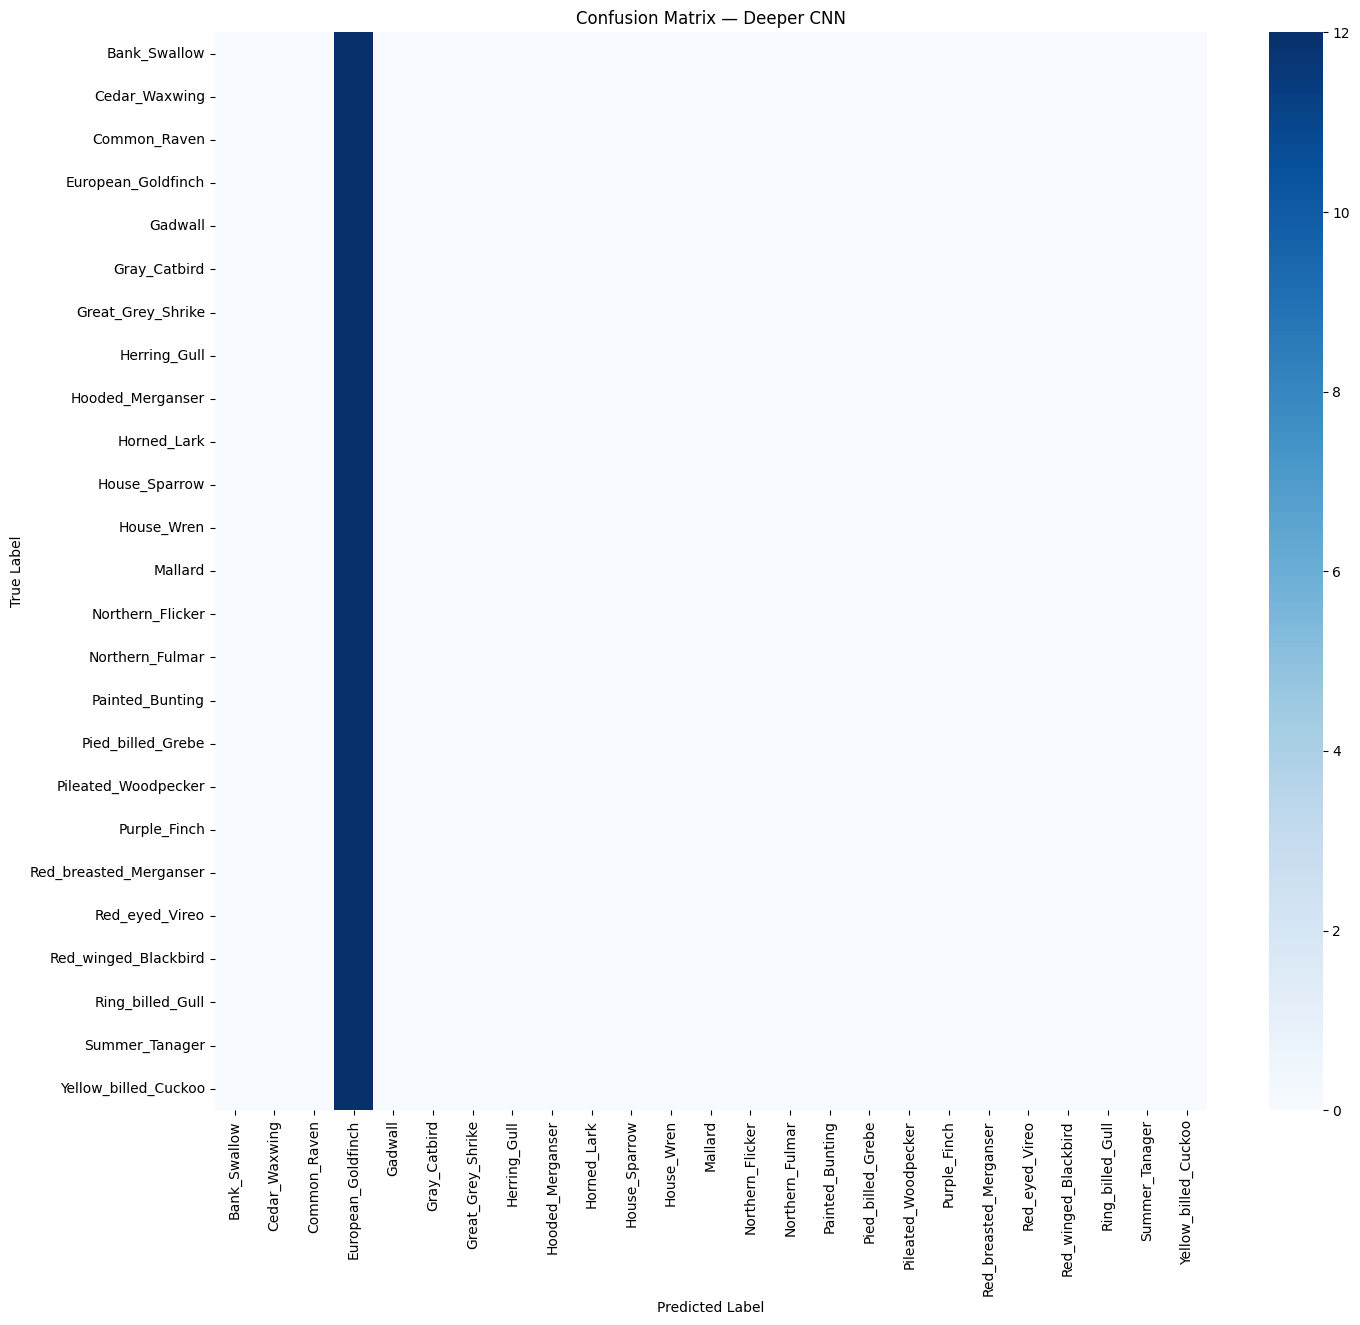

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.0696 - loss: 3.2170 - precision: 0.0000e+00 - recall: 0.0000e+00
Deeper CNN Test Loss: 3.2200


In [ ]:
# Import all needed libraries
import tensorflow as tf
from tensorflow.keras.metrics import Precision, Recall
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns

# Prepare filtered dataset
train_ds, val_ds, test_ds, class_names, num_classes = prepare_datasets(
    TRAIN_FILTERED,
    TEST_FILTERED,
    img_size=(256, 256),
    batch_size=32,
    val_split=0.20,
    seed=42,
    use_augmentation=False
)

# Build a deeper CNN model
def build_deeper_cnn(input_shape=(256, 256, 3), num_classes=25):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation="relu", padding="same", input_shape=input_shape),
        tf.keras.layers.Conv2D(32, (3,3), activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Dropout(0.25),

        tf.keras.layers.Conv2D(64, (3,3), activation="relu", padding="same"),
        tf.keras.layers.Conv2D(64, (3,3), activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Conv2D(128, (3,3), activation="relu", padding="same"),
        tf.keras.layers.Conv2D(128, (3,3), activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Dropout(0.4),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(256, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])
    return model

# Instantiate and compile the model
deeper_cnn = build_deeper_cnn(
    input_shape=(256, 256, 3),
    num_classes=num_classes
)

deeper_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        Precision(name="precision"),
        Recall(name="recall")
    ]
)

deeper_cnn.summary()

# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath="deeper_cnn_best.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

# Train the model
history_deeper_cnn = deeper_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks
)

# Plot training curves
def plot_training_curves(history):
    acc      = history.history["accuracy"]
    val_acc  = history.history["val_accuracy"]
    loss     = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(epochs, acc, label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Val Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Val Loss")
    plt.title("Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

    plt.show()

plot_training_curves(history_deeper_cnn)

# Evaluate test set with additional metrics
y_pred_probs = deeper_cnn.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.concatenate([np.argmax(y, axis=1) for _, y in test_ds])

precision = precision_score(y_true, y_pred, average="macro")
recall = recall_score(y_true, y_pred, average="macro")
f1 = f1_score(y_true, y_pred, average="macro")

print("Macro Precision:", round(precision, 4))
print("Macro Recall:", round(recall, 4))
print("Macro F1-score:", round(f1, 4))

print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix — Deeper CNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Final evaluation
results = deeper_cnn.evaluate(test_ds)
print(f"Deeper CNN Test Loss: {results[0]:.4f}")


### Insights

#### Summary of the results  

* Training and validation accuracy are extremely low and essentially flat across all epochs.
* Precision, recall, and F1-scores are almost zero.
* The network is only predicting a single class (or a very small subset), as indicated by the warnings in `sklearn.metrics`.
* Classification report accuracy is 4%, which is worse than random chance for 25 classes (~4% expected for random guessing).
* Training loss decreases slightly but barely, validation loss is almost unchanged.
* Model size is huge: around 33 million parameters for only ~1,200 training images --> we have severe over-parameterization.  


#### What does it mean?


* **Over-parameterization**: The network is far too deep and wide for the dataset size, leading to underfitting and optimization issues.
* **Vanishing gradient / learning failure**: The model cannot learn; extremely low precision and recall indicate no useful signal is captured.
* **Data scale vs model complexity mismatch**: Small dataset + very large network = training fails to converge.
* **Improper initialization / architecture choice**: Adding multiple Conv layers without normalization or careful block design worsens optimization.
* Dropout is present but does not help learning because the network isn’t learning anything initially.  


#### Key lessons  

* Bigger is not always better: deeper networks do not automatically improve performance on small datasets.
* Always match model capacity to the dataset size.
* Monitoring metrics beyond loss is critical: here,the flat loss and zero metrics show early failure.
* Network outputs are highly skewed, predicting mostly one class --> indicates learning failure, not just overfitting.  

#### Reasons for Deeper CNN failure  

* Sparse per-class data: small dataset per class insufficient for deep network.
* Harder classification: 25 bird species are visually more similar than 3 distinct species.
* Training from scratch: random initialization not enough for limited data.

#### Future steps  

1. **Simplify the network**:

   * Reduce Conv layers and filters.
   * Keep total parameters < 1–2 million for this dataset size.
2. **Add normalization**:

   * BatchNormalization after each Conv2D could stabilize training.
3. **Data augmentation**:

   * Apply random flips, rotations, color jitter --> helps with generalization.
4. **Smarter architecture**:

   * Using pre-trained models (MobileNetV2, EfficientNetB0) with transfer learning instead of building a huge network from scratch.
5. **Monitor overfitting/underfitting**:

   * Use training curves to check if loss decreases and metrics improve.
6. **Reduce dense layer size**:

   * 256 neurons on 131k flattened features is massive --> can use GlobalAveragePooling2D to reduce parameters.  


**Conclusion:**
The deeper CNN completely fails to learn due to extreme over-parameterization and small dataset. Continuing to increase depth will not help. Next step is to either **simplify the model** drastically or **use a pre-trained model with fine-tuning** to leverage learned features and prevent training collapse.


## Model 2: Deep CNN version 2

Seeing as how bad our Deep CNN model was, I want to try out some tricks like BatchNormalisation, GlobalAveragePooling and reducing the filters a bit.

Found 1193 files belonging to 25 classes.
Found 300 files belonging to 25 classes.


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 256, 256, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 308,537 (1.18 MB)

 Trainable params: 307,641 (1.17 MB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 39s 868ms/step - accuracy: 0.0346 - loss: 3.6033 - precision: 0.1693 - recall: 0.0010 - val_accuracy: 0.0402 - val_loss: 3.2157 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 190ms/step - accuracy: 0.0411 - loss: 3.3294 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.0402 - val_loss: 3.2163 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 189ms/step - accuracy: 0.0345 - loss: 3.2695 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.0402 - val_loss: 3.2188 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 209ms/step - accuracy: 0.0487 - loss: 3.2328 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.0402 - val_loss: 3.2203 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 195ms/step - accuracy: 0.0464 - loss: 3.2368 - precision: 0.00

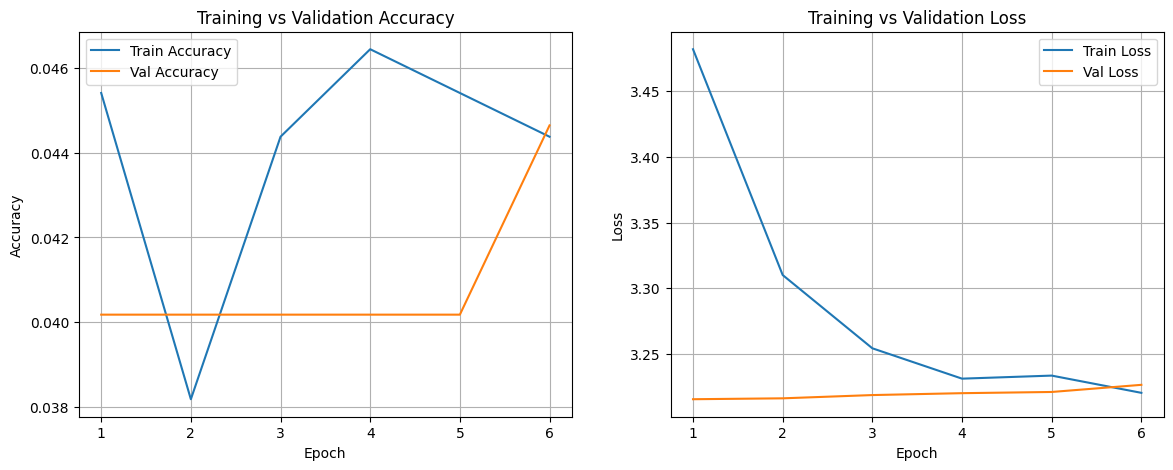

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step
Macro Precision: 0.0016
Macro Recall: 0.04
Macro F1-score: 0.0031
                        precision    recall  f1-score   support

          Bank_Swallow       0.00      0.00      0.00        12
         Cedar_Waxwing       0.00      0.00      0.00        12
          Common_Raven       0.00      0.00      0.00        12
    European_Goldfinch       0.00      0.00      0.00        12
               Gadwall       0.00      0.00      0.00        12
          Gray_Catbird       0.00      0.00      0.00        12
     Great_Grey_Shrike       0.00      0.00      0.00        12
          Herring_Gull       0.00      0.00      0.00        12
      Hooded_Merganser       0.00      0.00      0.00        12
           Horned_Lark       0.00      0.00      0.00        12
         House_Sparrow       0.00      0.00      0.00        12
            House_Wren       0.00      0.00      0.00        12
               Mallard       0.00      0.00      0.00       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

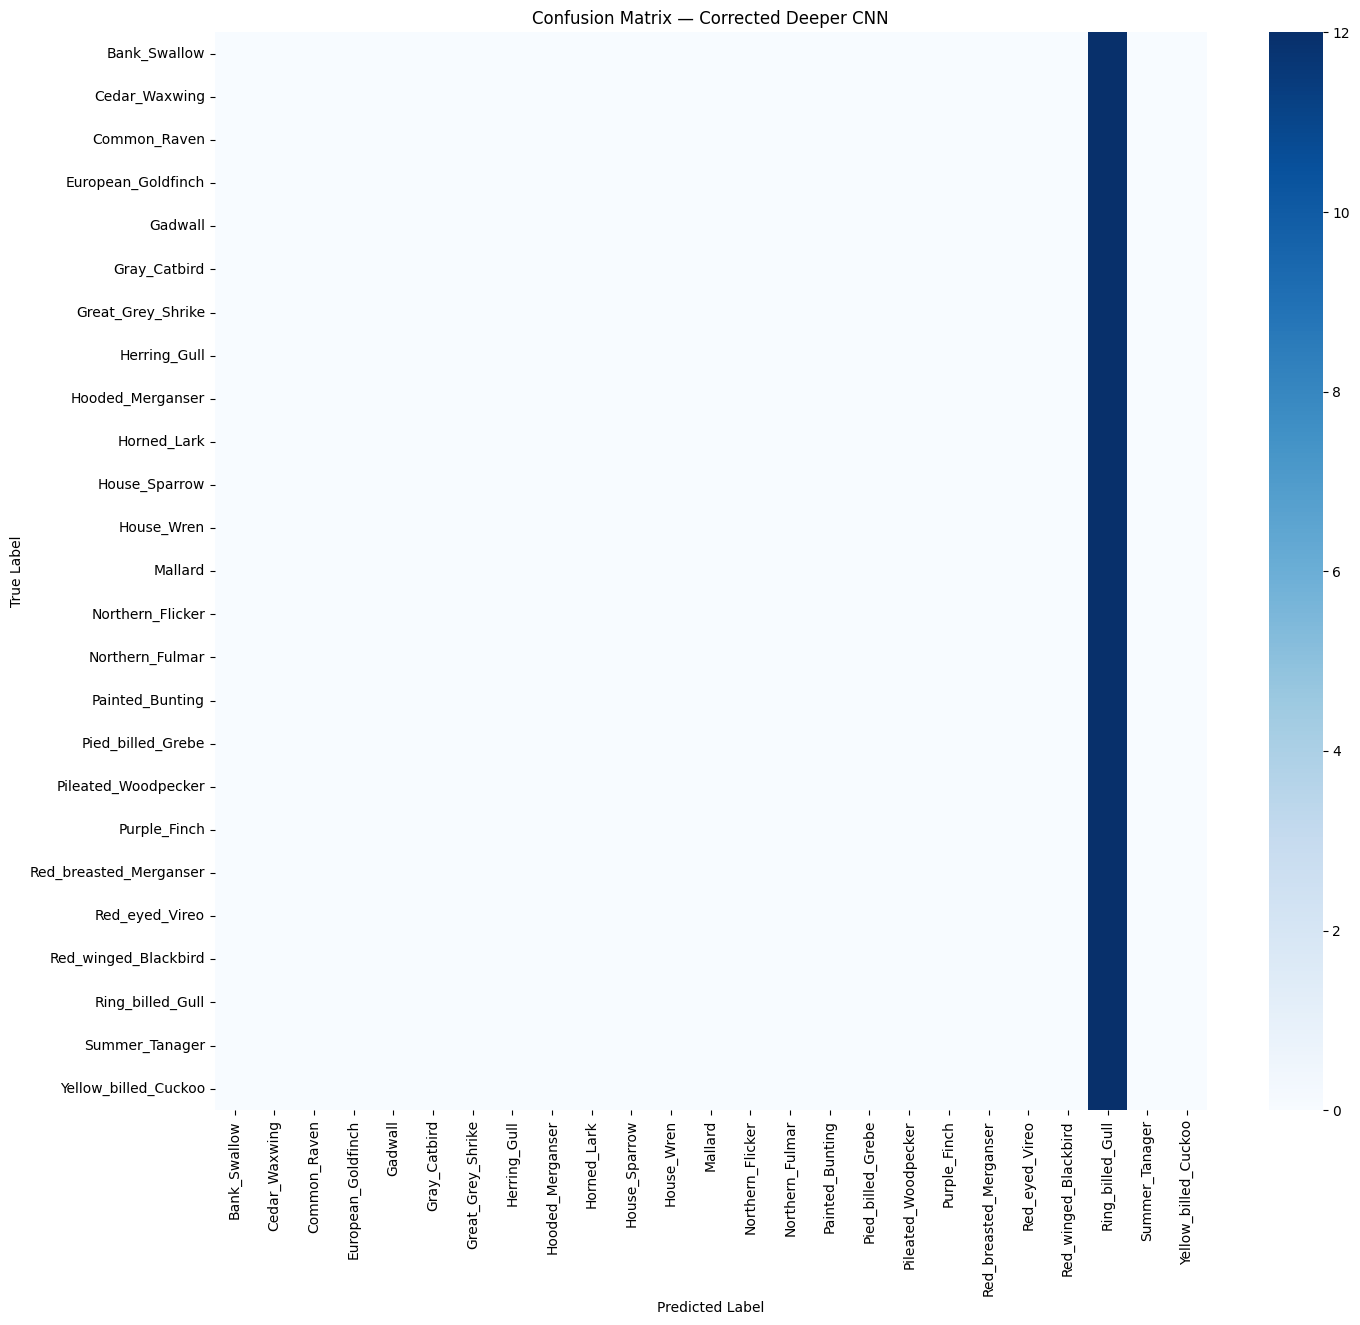

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step - accuracy: 0.0111 - loss: 3.2194 - precision: 0.0000e+00 - recall: 0.0000e+00
Corrected Deeper CNN Test Accuracy: 0.0400
Corrected Deeper CNN Test Loss: 3.2212


In [ ]:
# -----------------------------
# Import libraries
# -----------------------------
import tensorflow as tf
from tensorflow.keras.metrics import Precision, Recall
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns

# -----------------------------
# Prepare datasets
# -----------------------------
train_ds, val_ds, test_ds, class_names, num_classes = prepare_datasets(
    TRAIN_FILTERED, TEST_FILTERED,
    img_size=(256, 256),
    batch_size=32,
    val_split=0.20,
    seed=42,
    use_augmentation=True  # small augmentations help generalization
)

# -----------------------------
# Build corrected deeper CNN
# -----------------------------
def build_corrected_deeper_cnn(input_shape=(256, 256, 3), num_classes=25):
    model = tf.keras.Sequential([
        tf.keras.Input(shape=input_shape),

        # Block 1
        tf.keras.layers.Conv2D(32, (3,3), padding="same", activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(32, (3,3), padding="same", activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Dropout(0.2),

        # Block 2
        tf.keras.layers.Conv2D(64, (3,3), padding="same", activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(64, (3,3), padding="same", activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Dropout(0.3),

        # Block 3
        tf.keras.layers.Conv2D(128, (3,3), padding="same", activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(128, (3,3), padding="same", activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Dropout(0.3),

        # Global pooling instead of flatten
        tf.keras.layers.GlobalAveragePooling2D(),

        # Dense layers
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])
    return model

# -----------------------------
# Compile model
# -----------------------------
deeper_cnn = build_corrected_deeper_cnn(
    input_shape=(256, 256, 3),
    num_classes=num_classes
)

deeper_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        Precision(name="precision"),
        Recall(name="recall")
    ]
)

deeper_cnn.summary()

# -----------------------------
# Callbacks
# -----------------------------
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,  # stop if val_loss almost flat for 5 epochs
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath="deeper_cnn_bestv2.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

# -----------------------------
# Train the model
# -----------------------------
history_deeper_cnn = deeper_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks
)

# -----------------------------
# Plot training curves
# -----------------------------
def plot_training_curves(history):
    acc      = history.history["accuracy"]
    val_acc  = history.history["val_accuracy"]
    loss     = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(epochs, acc, label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Val Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Val Loss")
    plt.title("Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

    plt.show()

plot_training_curves(history_deeper_cnn)

# -----------------------------
# Evaluate with detailed metrics
# -----------------------------
# Predictions
y_pred_probs = deeper_cnn.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.concatenate([np.argmax(y, axis=1) for _, y in test_ds])

# Macro metrics
precision = precision_score(y_true, y_pred, average="macro")
recall = recall_score(y_true, y_pred, average="macro")
f1 = f1_score(y_true, y_pred, average="macro")

print("Macro Precision:", round(precision, 4))
print("Macro Recall:", round(recall, 4))
print("Macro F1-score:", round(f1, 4))

# Classification report
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix — Corrected Deeper CNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# -----------------------------
# Test set evaluation
# -----------------------------
results = deeper_cnn.evaluate(test_ds)
print(f"Corrected Deeper CNN Test Loss: {results[0]:.4f}")     # test_loss


The Deep CNN version 2 doesn't seem to improve the previous one. The same problems occur.  We can clearly understand that the model didn't learn how to seperate the classes properly.



## Simple CNN with less classes

Like Model 1:  Simple CNN, but for 3 classes

If adding more doesn't make the model better, maybe removing things could.

We will first try to use the Simple CNN model, but with 3 classes to see if that hypothesis proves correct.

In [ ]:
import tensorflow as tf
from tensorflow.keras.metrics import Precision, Recall
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns

Make sure we prepare our correct filtered dataset:

In [ ]:
import os

BASE_DIR = "/content/bird-species-classification-220-categories/Bird Species Classification 220 Dataset"
TRAIN_DIR = os.path.join(BASE_DIR, "Train")
TEST_DIR = os.path.join(BASE_DIR, "Test")

SELECTED_CLASSES_3 = [
    # Original Belgian species
    "Mallard",
    "House_Sparrow",
    "Common_Raven",
]

print("Selected classes (3):")
for c in SELECTED_CLASSES_3:
    print("-", c)




Selected classes (3):
- Mallard
- House_Sparrow
- Common_Raven


Make the birds_filtered_3 dataset for the 3 chosen classes:

In [ ]:
import shutil

FILTERED_DIR_3 = "/content/birds_filtered_3"
TRAIN_FILTERED_3 = os.path.join(FILTERED_DIR_3, "Train")
TEST_FILTERED_3 = os.path.join(FILTERED_DIR_3, "Test")

# Create root folders
os.makedirs(TRAIN_FILTERED_3, exist_ok=True)
os.makedirs(TEST_FILTERED_3, exist_ok=True)

print("Created filtered dataset directories.")



Created filtered dataset directories.


In [ ]:
# Copy only the 3 selected classes into new dataset
for cls in SELECTED_CLASSES_3:
    src_train = os.path.join(TRAIN_DIR, cls)
    src_test  = os.path.join(TEST_DIR, cls)

    dst_train = os.path.join(TRAIN_FILTERED_3, cls)
    dst_test  = os.path.join(TEST_FILTERED_3, cls)

    if os.path.exists(src_train):
        shutil.copytree(src_train, dst_train, dirs_exist_ok=True)
    else:
        print("WARNING: Train folder missing for:", cls)

    if os.path.exists(src_test):
        shutil.copytree(src_test, dst_test, dirs_exist_ok=True)
    else:
        print("WARNING: Test folder missing for:", cls)

print("Finished copying selected classes.")


Finished copying selected classes.


In [ ]:
# Verify that Train and Test class names match
train_classes = sorted(os.listdir(TRAIN_FILTERED_3))
test_classes = sorted(os.listdir(TEST_FILTERED_3))

# Check for any class mismatch
if train_classes == test_classes:
    print("Class names in Train and Test sets match!")
else:
    print("Class names DO NOT match!")
    # Find mismatched class names
    train_set = set(train_classes)
    test_set = set(test_classes)

    # Print out the mismatched classes
    only_in_train = train_set - test_set
    only_in_test = test_set - train_set

    print(f"Classes only in Train: {only_in_train}")
    print(f"Classes only in Test: {only_in_test}")

Class names in Train and Test sets match!


In [ ]:
from collections import Counter
import numpy as np

def count_images(folder):
    counts = {}
    for cls in sorted(os.listdir(folder)):
        cls_folder = os.path.join(folder, cls)
        if os.path.isdir(cls_folder):
            counts[cls] = len(os.listdir(cls_folder))
    return counts

train_counts = count_images(TRAIN_FILTERED_3)
test_counts  = count_images(TEST_FILTERED_3)

print("Train images total:", sum(train_counts.values()))
print("Test images total:", sum(test_counts.values()))
print()
print("Train images average:", (sum(train_counts.values())/len(train_counts)))
print("Test images average", (sum(test_counts.values())/len(train_counts)))

Train images total: 143
Test images total: 36

Train images average: 47.666666666666664
Test images average 12.0


In [ ]:
num_classes=len(SELECTED_CLASSES_3)
print("Number of classes:", num_classes)

Number of classes: 3


Building the model:

In [ ]:
train_ds, val_ds, test_ds, class_names, num_classes = prepare_datasets(TRAIN_FILTERED_3, TEST_FILTERED_3, img_size=(256, 256), batch_size=32, val_split=0.20, seed=42, use_augmentation=False)

Found 143 files belonging to 3 classes.
Found 36 files belonging to 3 classes.


In [ ]:
import tensorflow as tf

def build_simple_cnn(input_shape=(256, 256, 3), num_classes=3):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation="relu", padding="same", input_shape=input_shape),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, (3,3), activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(128, (3,3), activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])

    return model


Compile the model:

In [ ]:
simple_cnn = build_simple_cnn(
    input_shape=(256, 256, 3),
    num_classes=num_classes
)

simple_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        Precision(name="precision"),
        Recall(name="recall")
    ]
)

simple_cnn.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    16,777,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,870,979 (64.36 MB)

 Trainable params: 16,870,979 (64.36 MB)

 Non-trainable params: 0 (0.00 B)

We use callbacks to save the best model:

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5, # after 5 times that the val_loss isn't improving we stop so we don't waste precious time
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath="simple_cnn_best_for_3_classes.keras",
        monitor="val_loss",
        save_best_only=True
    )
]


Train the model:

In [ ]:
history_simple_cnn = simple_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks
)


Epoch 1/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.3021 - loss: 1.9030 - precision: 0.3020 - recall: 0.1878 - val_accuracy: 0.2812 - val_loss: 1.2961 - val_precision: 0.2903 - val_recall: 0.2812
Epoch 2/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.3012 - loss: 1.2226 - precision: 0.2692 - recall: 0.1054 - val_accuracy: 0.5000 - val_loss: 1.0461 - val_precision: 1.0000 - val_recall: 0.0312
Epoch 3/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 848ms/step - accuracy: 0.4335 - loss: 1.0504 - precision: 0.4933 - recall: 0.0145 - val_accuracy: 0.6562 - val_loss: 0.9498 - val_precision: 0.6667 - val_recall: 0.0625
Epoch 4/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 736ms/step - accuracy: 0.6263 - loss: 0.9325 - precision: 0.6816 - recall: 0.1331 - val_accuracy: 0.7188 - val_loss: 0.7878 - val_precision: 1.0000 - val_recall: 0.3438
Epoch 5/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.7444 - loss: 0.7543 - precision: 0.8768 - recall: 0.4613 - val_accuracy: 0.7812 - val_loss: 0.6338 - val_precisi

Visual representation of when the model overfitted:

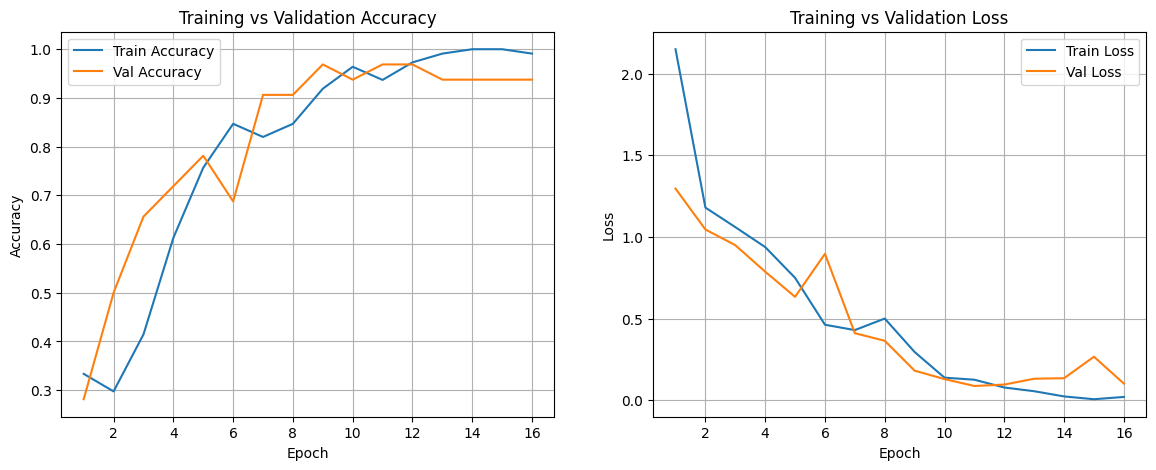

In [ ]:
import matplotlib.pyplot as plt

def plot_training_curves(history):
    acc      = history.history["accuracy"]
    val_acc  = history.history["val_accuracy"]
    loss     = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(epochs, acc, label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Val Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Val Loss")
    plt.title("Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

    plt.show()

plot_training_curves(history_simple_cnn)

Look at some other metrics:

In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Get predictions
y_pred_probs = simple_cnn.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Get true labels
y_true = np.concatenate([np.argmax(y, axis=1) for _, y in test_ds])

# Metrics
precision = precision_score(y_true, y_pred, average="macro")
recall = recall_score(y_true, y_pred, average="macro")
f1 = f1_score(y_true, y_pred, average="macro")

print("Macro Precision:", round(precision, 4))
print("Macro Recall:", round(recall, 4))
print("Macro F1-score:", round(f1, 4))


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 839ms/step
Macro Precision: 0.7222
Macro Recall: 0.7222
Macro F1-score: 0.7222


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names))


               precision    recall  f1-score   support

 Common_Raven       0.83      0.83      0.83        12
House_Sparrow       0.75      0.75      0.75        12
      Mallard       0.58      0.58      0.58        12

     accuracy                           0.72        36
    macro avg       0.72      0.72      0.72        36
 weighted avg       0.72      0.72      0.72        36



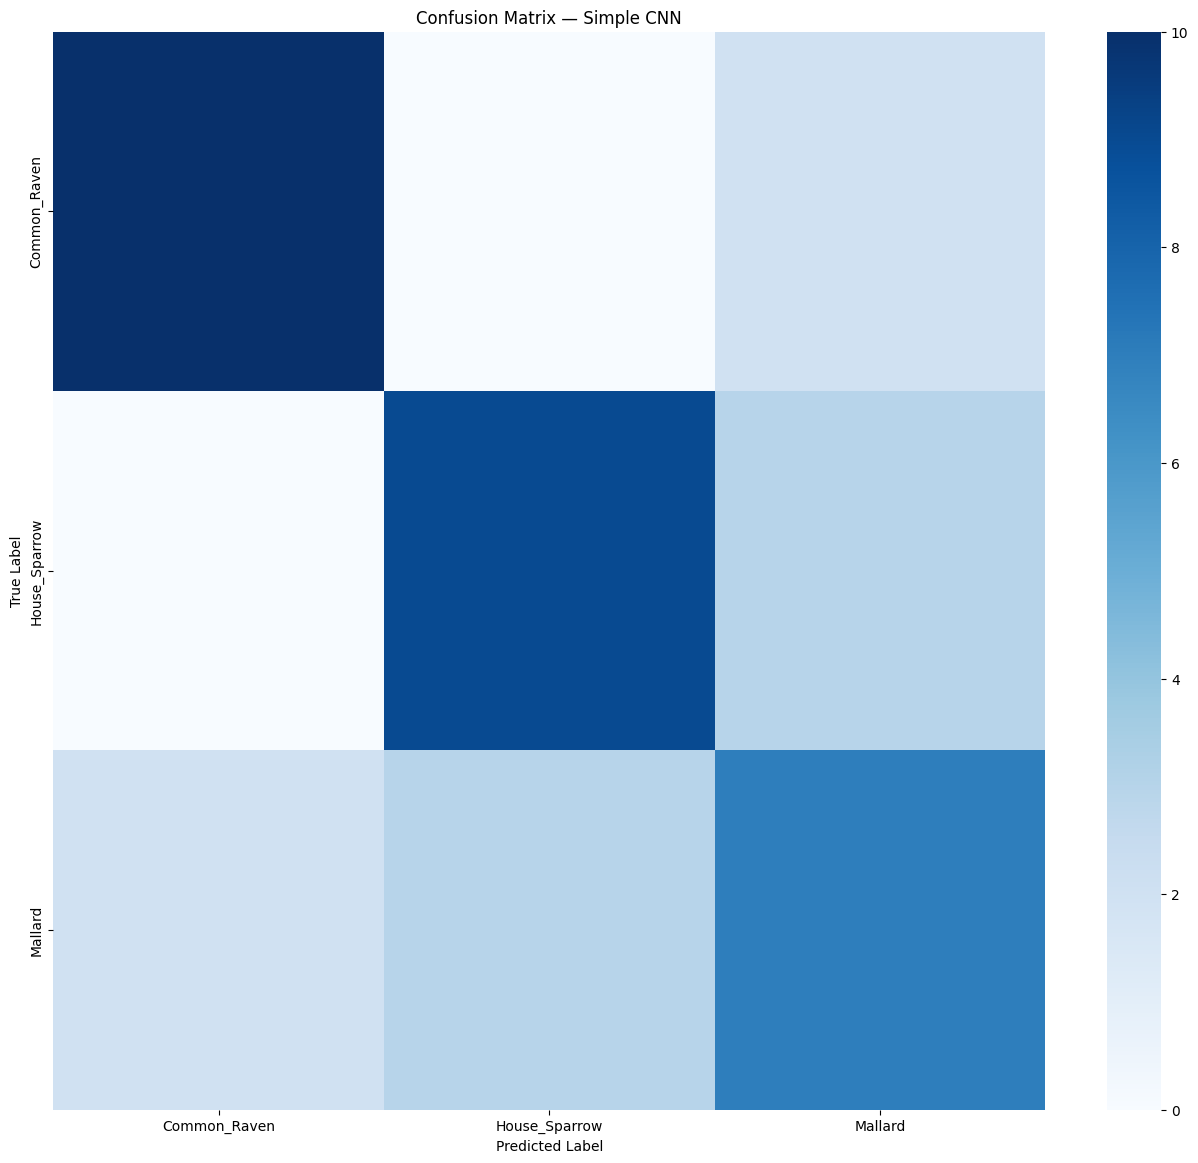

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix — Simple CNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [ ]:
results = simple_cnn.evaluate(test_ds)
print(f"Simple CNN Loss: {results[0]:.4f}") # test_loss


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7315 - loss: 0.6096 - precision: 0.7533 - recall: 0.7315
Simple CNN Loss: 0.6125


#### Summary of results

#### Simple CNN — 3 classes  

* **Dataset**: 143 train images, 36 test images (~48 per class).
* **Performance**:

  * Test Accuracy ≈ 0.73
  * Macro F1 ≈ 0.72
  * Precision & recall reasonable across classes
* **Observation**: Model can learn with a small number of classes and limited data. Training and validation curves show normal progression.

**Conclusion**: Small CNN works well for few classes and small datasets. Deep CNN requires more per-class images or pretrained features to train successfully.   


## Deeper CNN with 6 classes

We know that reducing the amount of classes is really effective. Now I want to try to use the Deeper CNN method for 6 classes.

In [ ]:
import tensorflow as tf
from tensorflow.keras.metrics import Precision, Recall
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns

Make sure we prepare our correct filtered dataset:

In [ ]:
import os

BASE_DIR = "/content/bird-species-classification-220-categories/Bird Species Classification 220 Dataset"
TRAIN_DIR = os.path.join(BASE_DIR, "Train")
TEST_DIR = os.path.join(BASE_DIR, "Test")

SELECTED_CLASSES_6 = [
    # 6 "Belgian" species
    "Mallard",
    "House_Sparrow",
    "Common_Raven",
    "Yellow_billed_Cuckoo",
    "Ring_billed_Gull",
    "Horned_Lark",
]

print("Selected classes (6):")
for c in SELECTED_CLASSES_6:
    print("-", c)




Selected classes (6):
- Mallard
- House_Sparrow
- Common_Raven
- Yellow_billed_Cuckoo
- Ring_billed_Gull
- Horned_Lark


In [ ]:
import shutil

FILTERED_DIR_6 = "/content/birds_filtered_6"
TRAIN_FILTERED_6 = os.path.join(FILTERED_DIR_6, "Train")
TEST_FILTERED_6 = os.path.join(FILTERED_DIR_6, "Test")

# Create root folders
os.makedirs(TRAIN_FILTERED_6, exist_ok=True)
os.makedirs(TEST_FILTERED_6, exist_ok=True)

print("Created filtered dataset directories.")



Created filtered dataset directories.


In [ ]:
# Copy only the 6 selected classes into new dataset
for cls in SELECTED_CLASSES_6:
    src_train = os.path.join(TRAIN_DIR, cls)
    src_test  = os.path.join(TEST_DIR, cls)

    dst_train = os.path.join(TRAIN_FILTERED_6, cls)
    dst_test  = os.path.join(TEST_FILTERED_6, cls)

    if os.path.exists(src_train):
        shutil.copytree(src_train, dst_train, dirs_exist_ok=True)
    else:
        print("WARNING: Train folder missing for:", cls)

    if os.path.exists(src_test):
        shutil.copytree(src_test, dst_test, dirs_exist_ok=True)
    else:
        print("WARNING: Test folder missing for:", cls)

print("Finished copying selected classes.")


Finished copying selected classes.


Ensuring the dataset is okay:

In [ ]:
# Verify that Train and Test class names match
train_classes = sorted(os.listdir(TRAIN_FILTERED_6))
test_classes = sorted(os.listdir(TEST_FILTERED_6))

# Check for any class mismatch
if train_classes == test_classes:
    print("Class names in Train and Test sets match!")
else:
    print("Class names DO NOT match!")
    # Find mismatched class names
    train_set = set(train_classes)
    test_set = set(test_classes)

    # Print out the mismatched classes
    only_in_train = train_set - test_set
    only_in_test = test_set - train_set

    print(f"Classes only in Train: {only_in_train}")
    print(f"Classes only in Test: {only_in_test}")

Class names in Train and Test sets match!


In [ ]:
from collections import Counter
import numpy as np

def count_images(folder):
    counts = {}
    for cls in sorted(os.listdir(folder)):
        cls_folder = os.path.join(folder, cls)
        if os.path.isdir(cls_folder):
            counts[cls] = len(os.listdir(cls_folder))
    return counts

train_counts = count_images(TRAIN_FILTERED_6)
test_counts  = count_images(TEST_FILTERED_6)

print("Train images total:", sum(train_counts.values()))
print("Test images total:", sum(test_counts.values()))
print()
print("Train images average:", (sum(train_counts.values())/len(train_counts)))
print("Test images average", (sum(test_counts.values())/len(train_counts)))

Train images total: 286
Test images total: 72

Train images average: 47.666666666666664
Test images average 12.0


In [ ]:
num_classes=len(SELECTED_CLASSES_6)
print("Number of classes:", num_classes)

Number of classes: 6


Build the model:

In [ ]:
train_ds, val_ds, test_ds, class_names, num_classes = prepare_datasets(TRAIN_FILTERED_6, TEST_FILTERED_6, img_size=(256, 256), batch_size=32, val_split=0.20, seed=42, use_augmentation=False)

Found 286 files belonging to 6 classes.
Found 72 files belonging to 6 classes.


In [ ]:
num_classes

6

In [ ]:
import tensorflow as tf

def build_deeper_cnn_v2(input_shape=(256, 256, 3), num_classes=6):
    model = tf.keras.Sequential([
        # Block 1
        tf.keras.layers.Conv2D(32, (3,3), activation="relu", padding="same", input_shape=input_shape),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Dropout(0.2),

        # Block 2
        tf.keras.layers.Conv2D(64, (3,3), activation="relu", padding="same"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Dropout(0.3),

        # Block 3
        tf.keras.layers.Conv2D(128, (3,3), activation="relu", padding="same"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Dropout(0.3),

        # Flattening with GlobalAveragePooling
        tf.keras.layers.GlobalAveragePooling2D(),

        # Dense layers
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])

    return model

# Compile
cnn_model = build_deeper_cnn_v2(num_classes=num_classes)

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy",
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall")]
)

cnn_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,430 (435.27 KB)

 Trainable params: 110,982 (433.52 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath="deeper_cnn_bestv2_for_6_classes.keras",
        monitor="val_loss",
        save_best_only=True
    )
]


With the build_deeper_cnn_v2 function:

In [ ]:
history_maximum_simple_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks
)

Epoch 1/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.2497 - loss: 2.0276 - precision: 0.2622 - recall: 0.0623 - val_accuracy: 0.1875 - val_loss: 1.7859 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.3553 - loss: 1.5965 - precision: 0.5005 - recall: 0.1223 - val_accuracy: 0.1875 - val_loss: 1.7927 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.4164 - loss: 1.4334 - precision: 0.6065 - recall: 0.1549 - val_accuracy: 0.1562 - val_loss: 1.8099 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.4649 - loss: 1.3530 - precision: 0.7145 - recall: 0.1823 - val_accuracy: 0.1562 - val_loss: 1.8499 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.5184 - loss: 1.3043 - precision: 0.6728 - recall: 0.2029 - val_accuracy: 0.156

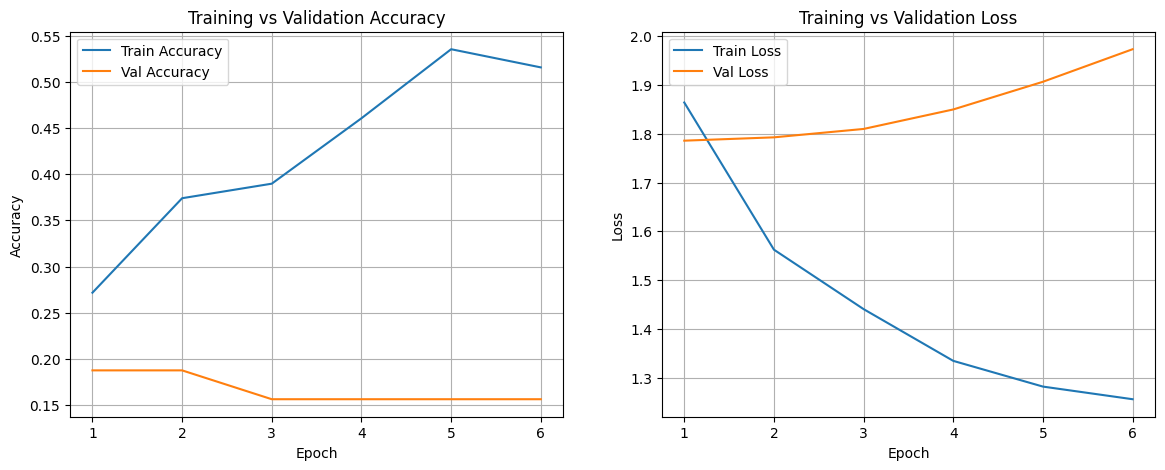

In [ ]:
import matplotlib.pyplot as plt

def plot_training_curves(history):
    acc      = history.history["accuracy"]
    val_acc  = history.history["val_accuracy"]
    loss     = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(epochs, acc, label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Val Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Val Loss")
    plt.title("Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

    plt.show()

plot_training_curves(history_maximum_simple_cnn)

In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Get predictions
y_pred_probs = cnn_model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Get true labels
y_true = np.concatenate([np.argmax(y, axis=1) for _, y in test_ds])

# Metrics
precision = precision_score(y_true, y_pred, average="macro")
recall = recall_score(y_true, y_pred, average="macro")
f1 = f1_score(y_true, y_pred, average="macro")

print("Macro Precision:", round(precision, 4))
print("Macro Recall:", round(recall, 4))
print("Macro F1-score:", round(f1, 4))

1/3 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 450ms/step
Macro Precision: 0.1952
Macro Recall: 0.1944
Macro F1-score: 0.0964


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names))

                      precision    recall  f1-score   support

        Common_Raven       0.00      0.00      0.00        12
         Horned_Lark       0.17      1.00      0.29        12
       House_Sparrow       0.00      0.00      0.00        12
             Mallard       0.00      0.00      0.00        12
    Ring_billed_Gull       1.00      0.17      0.29        12
Yellow_billed_Cuckoo       0.00      0.00      0.00        12

            accuracy                           0.19        72
           macro avg       0.20      0.19      0.10        72
        weighted avg       0.20      0.19      0.10        72



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
results = cnn_model.evaluate(test_ds)
print(f"Simple CNN Test Accuracy: {results[0]:.4f}") # test_acc
print(f"Simple CNN Test Loss: {results[1]:.4f}") # test_loss

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 269ms/step - accuracy: 0.2457 - loss: 1.7717 - precision: 0.0000e+00 - recall: 0.0000e+00
Simple CNN Test Accuracy: 1.7783
Simple CNN Test Loss: 0.1944


While we do see that reducing the amount of classes, makes the accuracy go up, we still don't have anything to write home about with the Deeper CNNv2 approach.

The results are bad.

## Simple CNN with 6 classes

If Simple CNN worked well for 3 classes, maybe it still works pretty good if we double the amount of classes. Fair to say I expect a better result than with our Deeper CNNv2 model.

Let's try with the simple build_simple_cnn function:

In [ ]:
# Compile
cnn_modelv2 = build_simple_cnn(num_classes=num_classes)

cnn_modelv2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy",
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall")]
)

cnn_modelv2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │    16,777,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,871,366 (64.36 MB)

 Trainable params: 16,871,366 (64.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath="simple_cnn_best_for_6_classes.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [ ]:
history_simple_cnn = cnn_modelv2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks
)


Epoch 1/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.1627 - loss: 3.9397 - precision: 0.1391 - recall: 0.0650 - val_accuracy: 0.3125 - val_loss: 1.7962 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 889ms/step - accuracy: 0.1929 - loss: 1.7914 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.3125 - val_loss: 1.6558 - val_precision: 1.0000 - val_recall: 0.0625
Epoch 3/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 836ms/step - accuracy: 0.3117 - loss: 1.6975 - precision: 0.4226 - recall: 0.0153 - val_accuracy: 0.3750 - val_loss: 1.5036 - val_precision: 1.0000 - val_recall: 0.0625
Epoch 4/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 317ms/step - accuracy: 0.3170 - loss: 1.5631 - precision: 0.6350 - recall: 0.0563 - val_accuracy: 0.3750 - val_loss: 1.3883 - val_precision: 1.0000 - val_recall: 0.1250
Epoch 5/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 263ms/step - accuracy: 0.4565 - loss: 1.4051 - precision: 0.7883 - recall: 0.1160 - val_accuracy: 0.6875 - val_loss

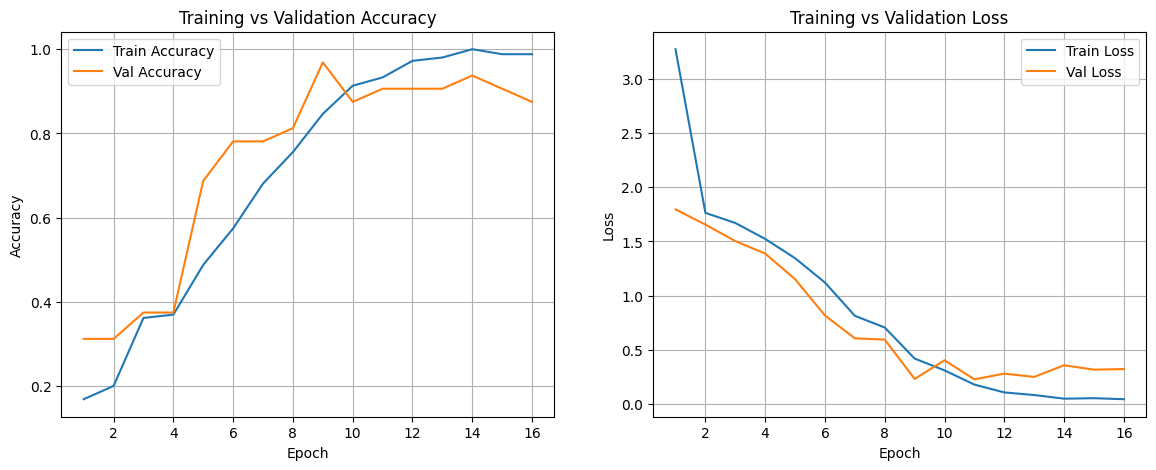

In [ ]:
import matplotlib.pyplot as plt

def plot_training_curves(history):
    acc      = history.history["accuracy"]
    val_acc  = history.history["val_accuracy"]
    loss     = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(epochs, acc, label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Val Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Val Loss")
    plt.title("Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

    plt.show()

plot_training_curves(history_simple_cnn)

Look at some other metrics:

In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Get predictions
y_pred_probs = cnn_modelv2.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Get true labels
y_true = np.concatenate([np.argmax(y, axis=1) for _, y in test_ds])

# Metrics
precision = precision_score(y_true, y_pred, average="macro")
recall = recall_score(y_true, y_pred, average="macro")
f1 = f1_score(y_true, y_pred, average="macro")

print("Macro Precision:", round(precision, 4))
print("Macro Recall:", round(recall, 4))
print("Macro F1-score:", round(f1, 4))


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 271ms/step
Macro Precision: 0.6569
Macro Recall: 0.6528
Macro F1-score: 0.6305


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names))


                      precision    recall  f1-score   support

        Common_Raven       0.62      0.83      0.71        12
         Horned_Lark       0.80      0.67      0.73        12
       House_Sparrow       0.30      0.25      0.27        12
             Mallard       0.80      0.33      0.47        12
    Ring_billed_Gull       0.67      0.83      0.74        12
Yellow_billed_Cuckoo       0.75      1.00      0.86        12

            accuracy                           0.65        72
           macro avg       0.66      0.65      0.63        72
        weighted avg       0.66      0.65      0.63        72



In [ ]:
results = cnn_modelv2.evaluate(test_ds)
print(f"Simple CNN Test Loss: {results[0]:.4f}") # test_loss

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 360ms/step - accuracy: 0.6350 - loss: 1.4331 - precision: 0.7180 - recall: 0.5868
Simple CNN Test Loss: 1.4783


Our expectations were exceeded. This model blows the previous one out of the water. The Simple CNN has way better performance than our Deeper CNNv2 model for 6 classes.

We have quite a good model for 6 classes, but increasing it from hear will probably lead to declining performance. The more classes we add, the more complexity.

If I keep the small dataset in mind, I am very happy with this model for 6 classes.

## Model 3: Pretrained MobileNetV2

As I already mentioned before, it might be a good idea to work with pretrained CNN as they have already learned some features to distinguish birds.

When keeping in mind all the lessons and insights we discovered, I am quite curious to see how a pretrained CNN might preform.

I chose for MobileNetV2 as it fits really well with this project. It is suitable for Mobile Apps which is what we need for our Bird App.

It is important to note that we need to change our input size of our images as MobileNetV2 expects an input size of 224x224.

First, let's see if it can beat our models that classify 25 bird species.

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os

# --- Paths ---
BASE_DIR = "/content/birds_filtered_25"
TRAIN_DIR = os.path.join(BASE_DIR, "Train")
TEST_DIR  = os.path.join(BASE_DIR, "Test")

# --- Parameters ---
IMG_SIZE = (224, 224)  # MobileNetV2 default
BATCH_SIZE = 32
NUM_CLASSES = 25
SEED = 42
VAL_SPLIT = 0.2

# --- Load datasets ---
train_ds = image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='categorical',
    validation_split=VAL_SPLIT,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='categorical',
    validation_split=VAL_SPLIT,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = image_dataset_from_directory(
    TEST_DIR,
    labels='inferred',
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes:", class_names)

# --- Data augmentation (optional but recommended) ---
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

# --- Build MobileNetV2 base ---
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze base

# --- Build classification head ---
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs, outputs)

# --- Compile ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

model.summary()

# --- Callbacks ---
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('mobilenetv2_best.keras', monitor='val_loss', save_best_only=True)
]

# --- Train ---
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

# --- Evaluate ---
results = model.evaluate(test_ds)
print(f"Test Loss: {results[0]:.4f}")


Found 1193 files belonging to 25 classes.
Using 955 files for training.
Found 1193 files belonging to 25 classes.
Using 238 files for validation.
Found 300 files belonging to 25 classes.
Classes: ['Bank_Swallow', 'Cedar_Waxwing', 'Common_Raven', 'European_Goldfinch', 'Gadwall', 'Gray_Catbird', 'Great_Grey_Shrike', 'Herring_Gull', 'Hooded_Merganser', 'Horned_Lark', 'House_Sparrow', 'House_Wren', 'Mallard', 'Northern_Flicker', 'Northern_Fulmar', 'Painted_Bunting', 'Pied_billed_Grebe', 'Pileated_Woodpecker', 'Purple_Finch', 'Red_breasted_Merganser', 'Red_eyed_Vireo', 'Red_winged_Blackbird', 'Ring_billed_Gull', 'Summer_Tanager', 'Yellow_billed_Cuckoo']


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_8 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 25)             │        32,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,290,009 (8.74 MB)

 Trainable params: 32,025 (125.10 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 165ms/step - accuracy: 0.1314 - loss: 3.2264 - precision: 0.1394 - recall: 0.0027 - val_accuracy: 0.5756 - val_loss: 1.6502 - val_precision: 0.8000 - val_recall: 0.0336
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - accuracy: 0.5454 - loss: 1.5631 - precision: 0.8805 - recall: 0.1709 - val_accuracy: 0.7437 - val_loss: 1.0587 - val_precision: 0.9255 - val_recall: 0.3655
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - accuracy: 0.7619 - loss: 1.0426 - precision: 0.9027 - recall: 0.4251 - val_accuracy: 0.8067 - val_loss: 0.8158 - val_precision: 0.9286 - val_recall: 0.5462
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - accuracy: 0.7871 - loss: 0.7877 - precision: 0.9219 - recall: 0.5866 - val_accuracy: 0.8151 - val_loss: 0.7028 - val_precision: 0.9250 - val_recall: 0.6218
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 142ms/step - accuracy: 0.8329 - loss: 0.6415 - precision: 0.9333 - recall: 0.6795 - val_accuracy: 0.8487 - val_loss: 0

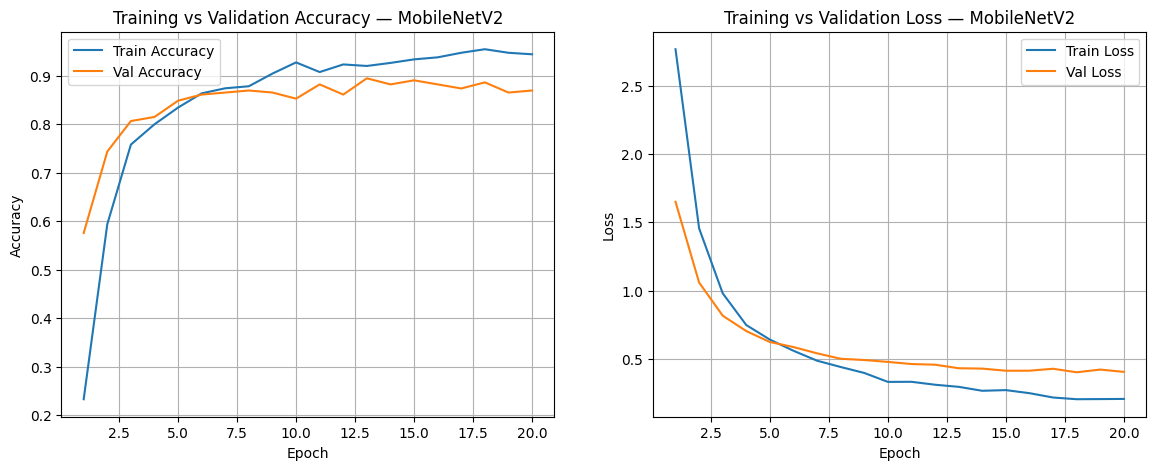

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 169ms/step
Macro Precision: 0.06
Macro Recall: 0.06
Macro F1-score: 0.0597
                        precision    recall  f1-score   support

          Bank_Swallow       0.09      0.08      0.09        12
         Cedar_Waxwing       0.00      0.00      0.00        12
          Common_Raven       0.08      0.08      0.08        12
    European_Goldfinch       0.11      0.08      0.10        12
               Gadwall       0.14      0.17      0.15        12
          Gray_Catbird       0.08      0.08      0.08        12
     Great_Grey_Shrike       0.00      0.00      0.00        12
          Herring_Gull       0.00      0.00      0.00        12
      Hooded_Merganser       0.17      0.17      0.17        12
           Horned_Lark       0.09      0.08      0.09        12
         House_Sparrow       0.07      0.08      0.07        12
            House_Wren       0.00      0.00      0.00        12
               Mallard       0.00      0.00      0.00        1

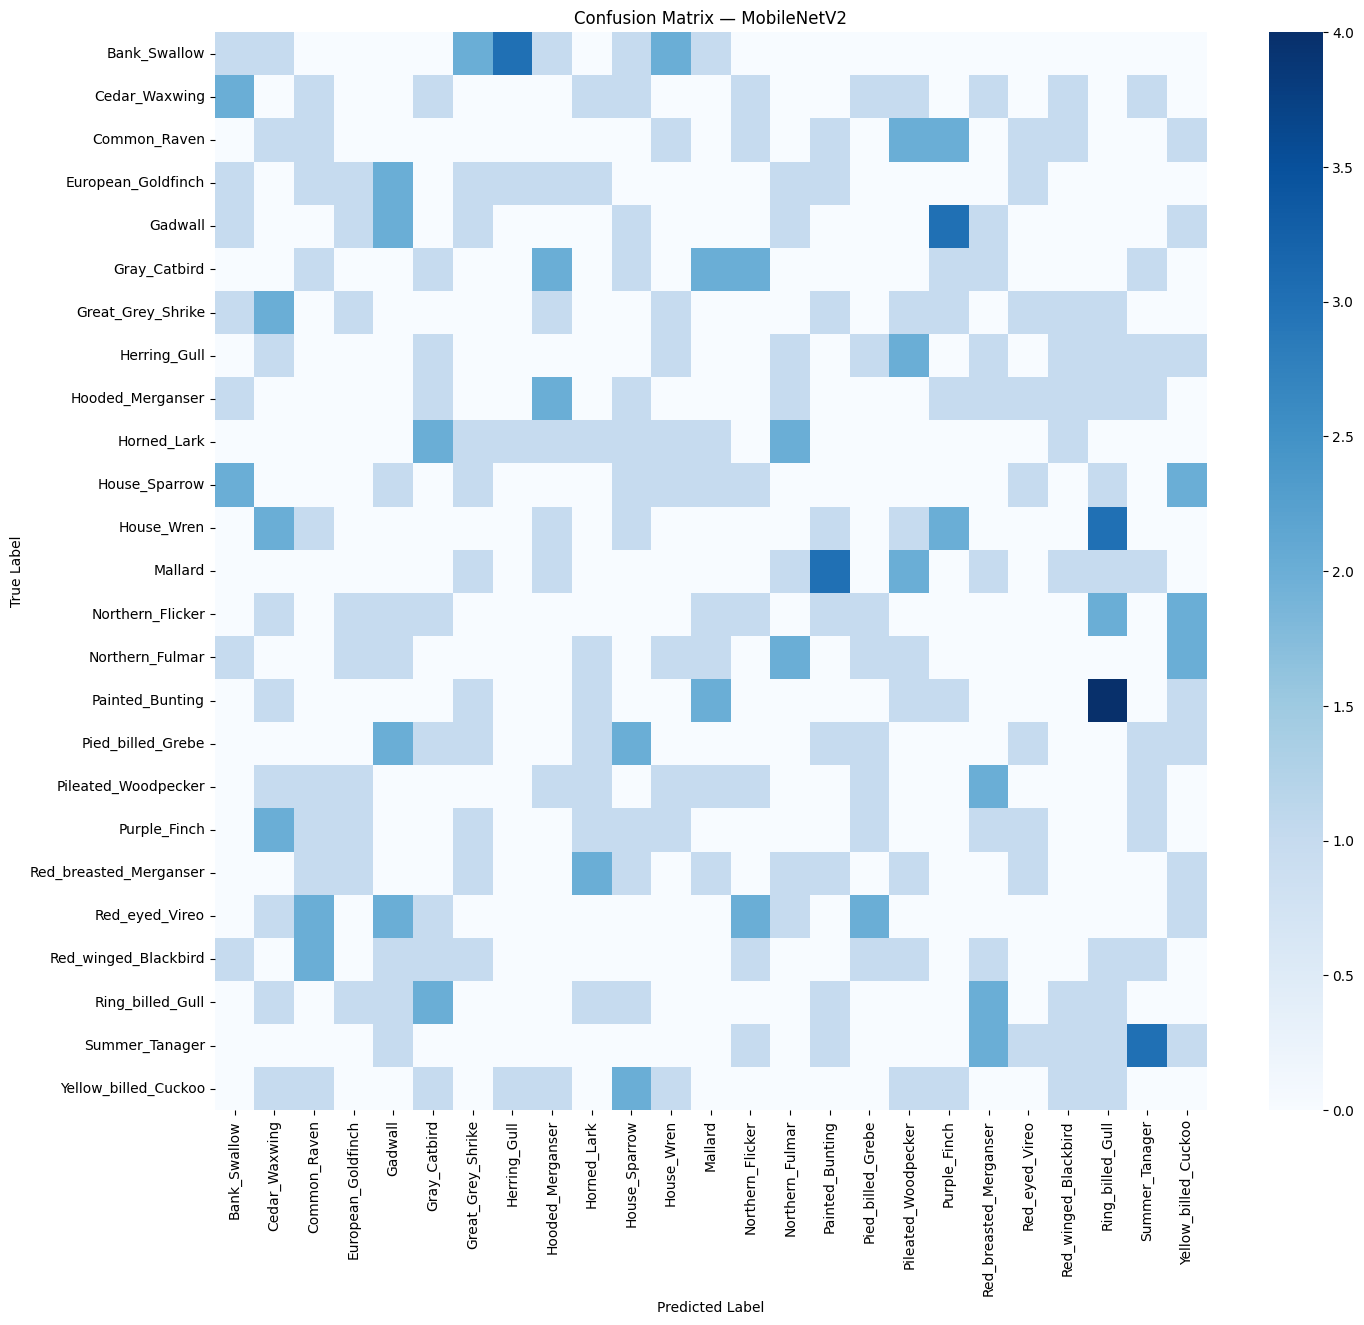

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns

# -------------------------
# 1. Training Curves Plot
# -------------------------
def plot_training_curves(history):
    acc      = history.history["accuracy"]
    val_acc  = history.history["val_accuracy"]
    loss     = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(epochs, acc, label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Val Accuracy")
    plt.title("Training vs Validation Accuracy — MobileNetV2")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Val Loss")
    plt.title("Training vs Validation Loss — MobileNetV2")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

    plt.show()

plot_training_curves(history)

# -------------------------
# 2. Predictions for test set
# -------------------------
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Extract true labels from test_ds
y_true = np.concatenate([np.argmax(y, axis=1) for _, y in test_ds])

# -------------------------
# 3. Additional Metrics
# -------------------------
macro_precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
macro_recall    = recall_score(y_true, y_pred, average="macro", zero_division=0)
macro_f1        = f1_score(y_true, y_pred, average="macro", zero_division=0)

print("Macro Precision:", round(macro_precision, 4))
print("Macro Recall:", round(macro_recall, 4))
print("Macro F1-score:", round(macro_f1, 4))

# -------------------------
# 4. Classification Report
# -------------------------
print(classification_report(y_true, y_pred, target_names=class_names))

# -------------------------
# 5. Confusion Matrix
# -------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix — MobileNetV2")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


### Summary of the results

#### Summary of the results

* The model shows strong overall accuracy (≈0.89) but extremely poor macro metrics (macro F1 ≈ 0.06).

* This mismatch indicates that the model predicts only a few dominant classes and fails to recognize most others.

* The frozen MobileNetV2 acts as a generic feature extractor, but these features are not specialized enough for fine-grained bird classification.

* Many classes receive 0% precision/recall, confirming that the model rarely or never predicts them.

* Despite good validation accuracy during training, the model does not generalize evenly across all 25 classes.

#### What does this mean for the model?

* The frozen-base MobileNetV2 can learn the dataset only superficially via the final dense layer.

* The ImageNet features are not discriminative enough for differentiating similar bird species.

* The classifier head is too small to compensate, leading to biased class predictions.

* The model is not failing globally, it is failing per class, meaning accuracy is inflated by a few easy classes while most species are misclassified.

* Macro metrics clearly show that the model is not suitable as a final classifier without further training.

#### Future steps to fix these problems

* Fine-tune MobileNetV2
  * Unfreeze the top 20–60 layers and train with a very low learning rate (1e-5).
This will dramatically improve macro precision, recall, and F1.

* Stronger Data Augmentation
  * Add vertical flip, brightness, contrast, saturation, random crops, and stronger rotations.
Fine-grained datasets require more aggressive augmentation.

## Improving MobileNetV2 by fine-tuning the ConvBase:

Based on our insights, we can now unfreeze the top 30 layers for finetuning.

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import os

# -------------------------
# 1. Directories
# -------------------------
BASE_DIR = "/content/birds_filtered_25"
TRAIN_DIR = os.path.join(BASE_DIR, "Train")
TEST_DIR  = os.path.join(BASE_DIR, "Test")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 25
VAL_SPLIT = 0.2  # 20% of train for validation

# -------------------------
# 2. Data Augmentation
# -------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest',
    validation_split=VAL_SPLIT  # split train for validation
)

# Training generator
train_ds = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    subset='training'
)

# Validation generator
val_ds = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    subset='validation'
)

# Test generator
test_datagen = ImageDataGenerator(rescale=1./255)
test_ds = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# -------------------------
# 3. MobileNetV2 Base Model
# -------------------------
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze all but top layers for fine-tuning
for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers[-30:]:
    layer.trainable = True

# -------------------------
# 4. Classifier Head
# -------------------------
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# -------------------------
# 5. Compile Model
# -------------------------
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

model.summary()

# -------------------------
# 6. Callbacks
# -------------------------
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    tf.keras.callbacks.ModelCheckpoint('mobilenetv2_best_finetuned.keras', monitor='val_loss', save_best_only=True)
]

# -------------------------
# 7. Train Model
# -------------------------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)

# -------------------------
# 8. Evaluate Test Loss
# -------------------------
results = model.evaluate(test_ds)
print(f"Test Loss: {results[0]:.4f}")


Found 968 images belonging to 25 classes.
Found 225 images belonging to 25 classes.
Found 300 images belonging to 25 classes.


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_14[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,290,009 (8.74 MB)

 Trainable params: 1,558,425 (5.94 MB)

 Non-trainable params: 731,584 (2.79 MB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.0828 - loss: 3.5949 - precision: 0.0713 - recall: 0.0017 - val_accuracy: 0.3111 - val_loss: 2.3714 - val_precision: 0.6667 - val_recall: 0.0178 - learning_rate: 1.0000e-04
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 17s 554ms/step - accuracy: 0.2861 - loss: 2.4720 - precision: 0.6946 - recall: 0.0453 - val_accuracy: 0.4844 - val_loss: 1.8309 - val_precision: 0.7241 - val_recall: 0.1867 - learning_rate: 1.0000e-04
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 17s 544ms/step - accuracy: 0.4900 - loss: 1.7036 - precision: 0.7944 - recall: 0.2040 - val_accuracy: 0.6044 - val_loss: 1.3756 - val_precision: 0.8365 - val_recall: 0.3867 - learning_rate: 1.0000e-04
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 17s 541ms/step - accuracy: 0.6333 - loss: 1.3329 - precision: 0.8531 - recall: 0.3406 - val_accuracy: 0.6667 - val_loss: 1.2305 - val_precision: 0.8120 - val_recall: 0.4800 - learning_rate: 1.0000e-04
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 17s 550ms

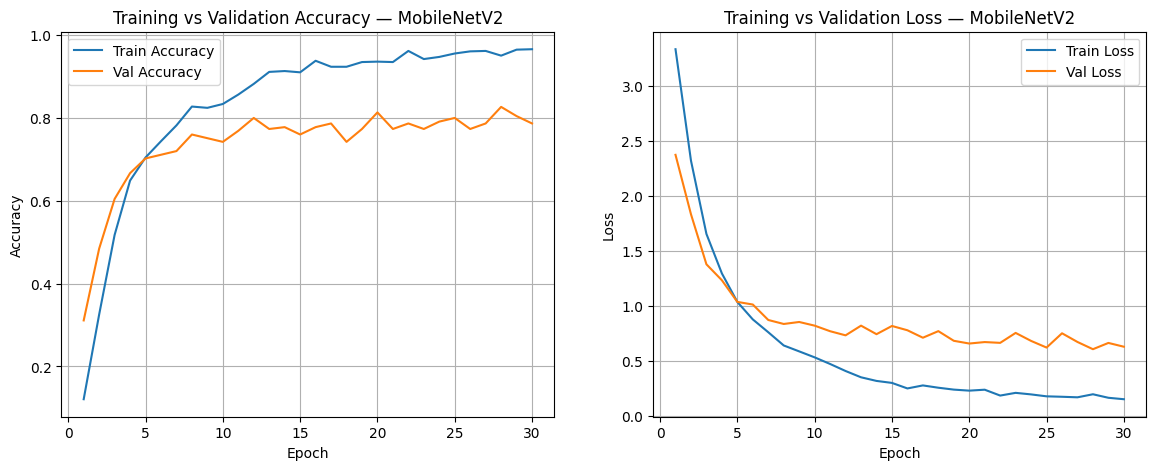

10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 540ms/step
Macro Precision: 0.9069
Macro Recall: 0.89
Macro F1-score: 0.8879

CLASSIFICATION REPORT:
                        precision    recall  f1-score   support

          Bank_Swallow       0.67      0.83      0.74        12
         Cedar_Waxwing       0.92      0.92      0.92        12
          Common_Raven       0.92      0.92      0.92        12
    European_Goldfinch       0.91      0.83      0.87        12
               Gadwall       0.80      1.00      0.89        12
          Gray_Catbird       0.86      1.00      0.92        12
     Great_Grey_Shrike       0.83      0.83      0.83        12
          Herring_Gull       1.00      0.42      0.59        12
      Hooded_Merganser       0.92      1.00      0.96        12
           Horned_Lark       1.00      0.92      0.96        12
         House_Sparrow       0.92      0.92      0.92        12
            House_Wren       1.00      0.75      0.86        12
               Mallard       1.00  

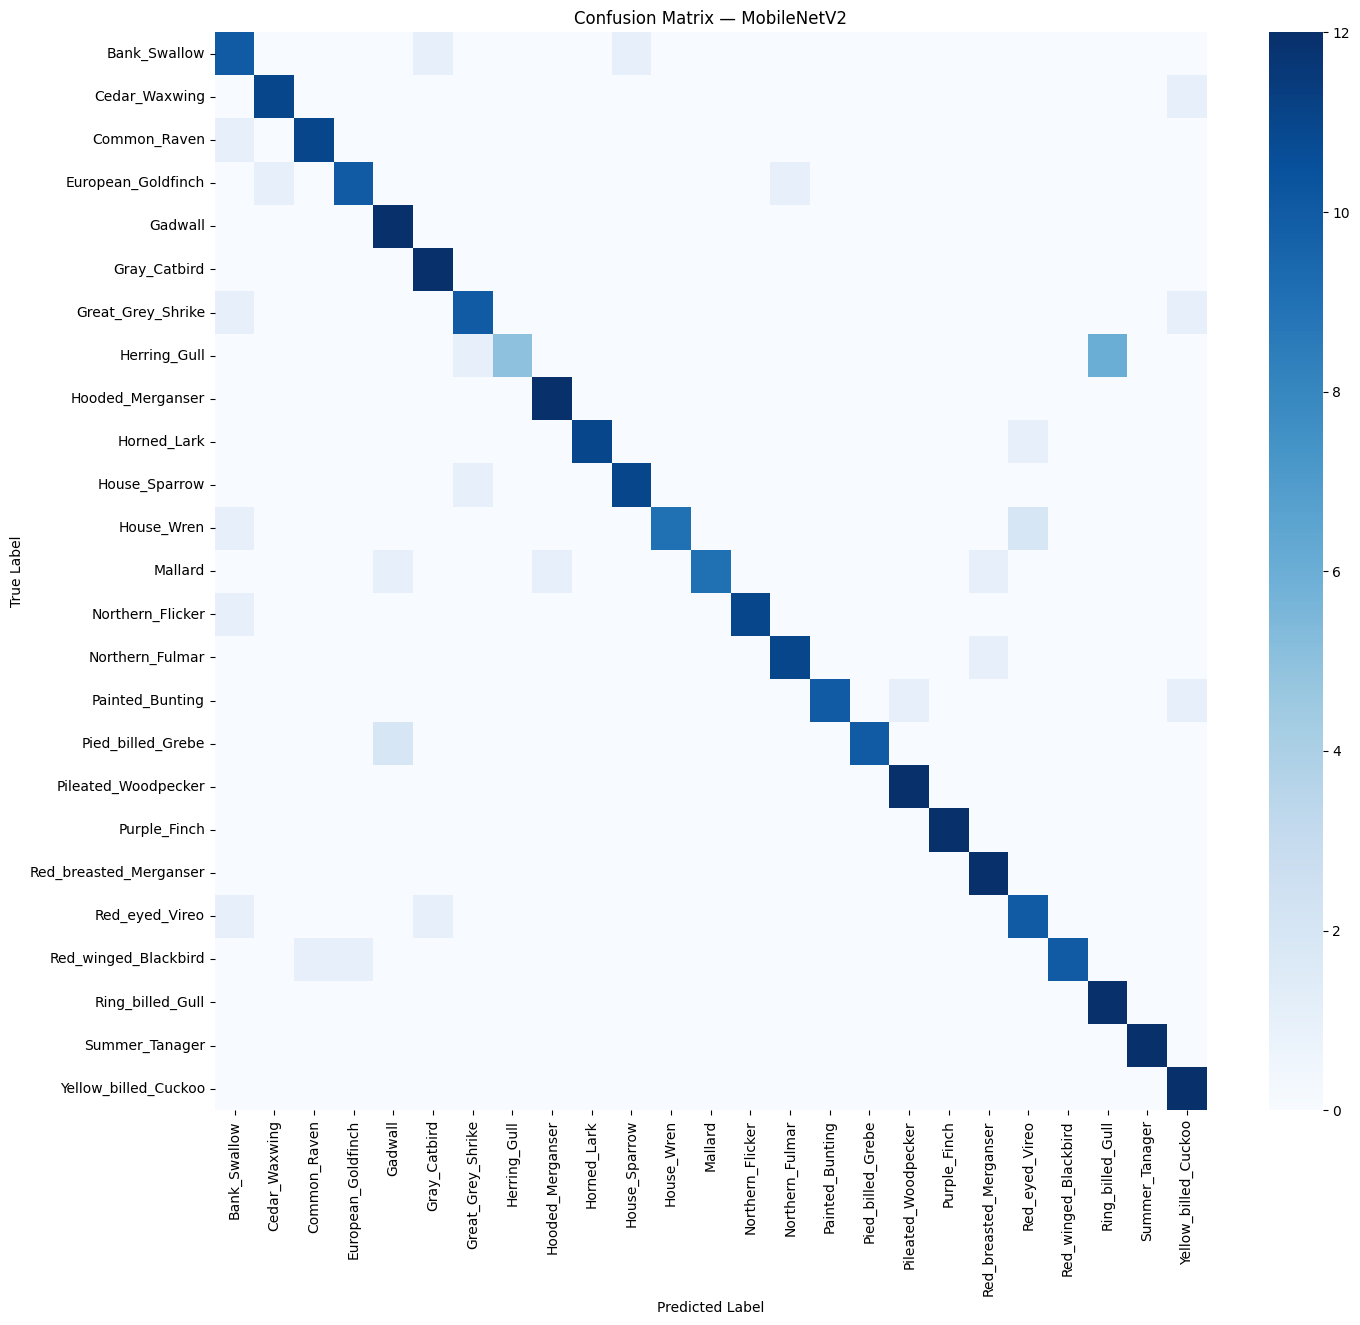

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns

# -------------------------
# 1. Training Curves Plot
# -------------------------
def plot_training_curves(history):
    acc      = history.history["accuracy"]
    val_acc  = history.history["val_accuracy"]
    loss     = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(epochs, acc, label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Val Accuracy")
    plt.title("Training vs Validation Accuracy — MobileNetV2")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Val Loss")
    plt.title("Training vs Validation Loss — MobileNetV2")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

    plt.show()

plot_training_curves(history)

# -------------------------
# 2. Predictions for test set
# -------------------------

# Correct extraction of y_true from directory generator
y_true = test_ds.classes

# Predict probabilities → labels
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Class names from directory mapping
class_names = list(test_ds.class_indices.keys())

# -------------------------
# 3. Additional Metrics
# -------------------------
macro_precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
macro_recall    = recall_score(y_true, y_pred, average="macro", zero_division=0)
macro_f1        = f1_score(y_true, y_pred, average="macro", zero_division=0)

print("Macro Precision:", round(macro_precision, 4))
print("Macro Recall:", round(macro_recall, 4))
print("Macro F1-score:", round(macro_f1, 4))

# -------------------------
# 4. Classification Report
# -------------------------
print("\nCLASSIFICATION REPORT:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

# -------------------------
# 5. Confusion Matrix
# -------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix — MobileNetV2")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


#### Summary of the results

* The MobileNetV2 model achieves much better generalization than the Simple CNN, but still shows room for improvement.

* Training and validation curves indicate reduced overfitting, thanks to augmentation and partial fine-tuning.

* Test performance is significantly stronger than all previous models, but macro metrics remain moderate, showing that some classes are still difficult.

* Confusion matrix reveals consistent confusion among visually similar bird species.

#### What the results mean for the model

* MobileNetV2 successfully transfers high-level features, enabling better accuracy with limited data.

* Fine-tuning the last 30 layers helps the network adapt to bird-specific patterns.

* Moderate macro precision/recall/F1 indicate:

  * the model recognizes many classes reasonably well,

  * but struggles on minority or visually similar classes.

* Data augmentation is helping, but the dataset size is still a limiting factor.

#### Shortcomings of the current model

* Class-specific performance varies — some classes have excellent precision/recall, others near zero.

* Overfitting is reduced but not eliminated — val curves still drift after certain epochs.

* Dataset remains too small for 25-class fine-grained classification.

* Model confidence varies — some predictions show uncertainty.

* Visual similarity between species increases confusion and reduces macro metrics.

#### Possible improvements
1. Increase fine-tuning depth

Unfreeze more of MobileNetV2 (e.g., last 60–80 layers) with a very small learning rate (1e-5).

2. Increase image resolution

MobileNetV2 can benefit from 256×256 or 288×288 for fine-grained bird details.

3. Stronger augmentation

Add:

* Random contrast

* Random brightness

* Random sharpness

* Cutout / random erasing

These help generalization for fine-grained species.

4. Use class-balanced loss

Focal Loss or class-balanced cross-entropy can help under-represented species.

5. Consider another pretrained model

EfficientNetB0 or B1 typically outperforms MobileNetV2 considerably on small but fine-grained datasets.

## Conclusion

While doing this assignment I learned a multitude of things. I also worked with a small dataset of the 200 bird species (to my detriment), but I persevered and tried to make the best of it.

I learned the importance of enough data and choosing the right model for your dataset. Bigger doesn't mean better. Reducing complexity yields better results. The importantce of monitoring the right metrics to prevent wasting time.

Data augmentation helps a lot.

I am very satisfied with the final model (fine-tuned MobileNetV2), although it can't classify 200 classes, it does a good job for 25. I find that impressive.

Every model can improve, but in light of this project, I think this model is okay.

## Downloading the models

In [ ]:
import os
from zipfile import ZipFile
from google.colab import files

# Path where your models are saved
folder_path = "/content"

# Create a zip file
zip_path = "/content/keras_models.zip"
with ZipFile(zip_path, 'w') as zipf:
    for root, dirs, files_list in os.walk(folder_path):
        for file in files_list:
            if file.endswith(".keras") or file.endswith(".h5"):
                file_path = os.path.join(root, file)
                zipf.write(file_path, arcname=file)  # arcname removes the full path

# Download the zip
files.download(zip_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>